## 0. Import libs

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, VotingRegressor,RandomForestRegressor,VotingClassifier
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
from sklearn.svm import SVC,SVR
from sklearn.metrics import classification_report, roc_auc_score
import joblib


## 1. Parsing date

In [2]:
df=pd.read_csv("../datasets/epi_r.csv")
df

,title,rating,calories,protein,fat,sodium,#cakeweek,#wasteless,22-minute meals,3-ingredient recipes,...,yellow squash,yogurt,yonkers,yuca,zucchini,cookbooks,leftovers,snack,snack week,turkey
0,"Lentil, Apple, and Turkey Wrap",2.500,426.0,30.0,7.0,559.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,Boudin Blanc Terrine with Red Onion Confit,4.375,403.0,18.0,23.0,1439.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Potato and Fennel Soup Hodge,3.750,165.0,6.0,7.0,165.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Mahi-Mahi in Tomato Olive Sauce,5.000,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Spinach Noodle Casserole,3.125,547.0,20.0,32.0,452.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20047,Parmesan Puffs,3.125,28.0,2.0,2.0,64.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20048,Artichoke and Parmesan Risotto,4.375,671.0,22.0,28.0,583.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20049,Turkey Cream Puff Pie,4.375,563.0,31.0,38.0,652.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
20050,Snapper on Angel Hair with Citrus Cream,4.375,631.0,45.0,24.0,517.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
col=df.value_counts()

In [4]:
col

title                                        rating  calories  protein  fat   sodium  #cakeweek  #wasteless  22-minute meals  3-ingredient recipes  30 days of groceries  advance prep required  alabama  alaska  alcoholic  almond  amaretto  anchovy  anise  anniversary  anthony bourdain  aperitif  appetizer  apple  apple juice  apricot  arizona  artichoke  arugula  asian pear  asparagus  aspen  atlanta  australia  avocado  back to school  backyard bbq  bacon  bake  banana  barley  basil  bass  bastille day  bean  beef  beef rib  beef shank  beef tenderloin  beer  beet  bell pepper  berry  beverly hills  birthday  biscuit  bitters  blackberry  blender  blue cheese  blueberry  boil  bok choy  bon appétit  bon app��tit  boston  bourbon  braise  bran  brandy  bread  breadcrumbs  breakfast  brie  brine  brisket  broccoli  broccoli rabe  broil  brooklyn  brown rice  brownie  brunch  brussel sprout  buffalo  buffet  bulgaria  bulgur  burrito  butter  buttermilk  butternut squash  butterscotch/ca

In [5]:
ingredients = [
    'almond',
    'amaretto',
    'anchovy',
    'anise',
    'apple',
    'apple juice',
    'apricot',
    'artichoke',
    'arugula',
    'asian pear',
    'asparagus',
    'avocado',
    'bacon',
    'banana',
    'barley',
    'basil',
    'bass',
    'bean',
    'beef',
    'beef rib',
    'beef shank',
    'beef tenderloin',
    'beer',
    'beet',
    'bell pepper',
    'berry',
    'bitters',
    'blackberry',
    'blue cheese',
    'blueberry',
    'bok choy',
    'bourbon',
    'bran',
    'brandy',
    'bread',
    'breadcrumbs',
    'brie',
    'brisket',
    'broccoli',
    'broccoli rabe',
    'brown rice',
    'brownie',
    'brussel sprout',
    'bulgur',
    'butter',
    'buttermilk',
    'butternut squash',
    'butterscotch/caramel',
    'cabbage',
    'cake',
    'calvados',
    'campari',
    'candy',
    'cantaloupe',
    'capers',
    'caraway',
    'cardamom',
    'carrot',
    'cashew',
    'cauliflower',
    'caviar',
    'celery',
    'chambord',
    'champagne',
    'chard',
    'chartreuse',
    'cheddar',
    'cheese',
    'cherry',
    'chestnut',
    'chicken',
    'chickpea',
    'chile',
    'chile pepper',
    'chili',
    'chive',
    'chocolate',
    'cilantro',
    'cinnamon',
    'citrus',
    'clam',
    'clove',
    'coconut',
    'cod',
    'coffee',
    'cognac/armagnac',
    'collard greens',
    'condiment/spread',
    'cookie',
    'cookies',
    'coriander',
    'corn',
    'cornmeal',
    'cottage cheese',
    'couscous',
    'crab',
    'cranberry',
    'cranberry sauce',
    'cream cheese',
    'créme de cacao',
    'cr��me de cacao',
    'cucumber',
    'cumin',
    'cupcake',
    'currant',
    'curry',
    'custard',
    'date',
    'dill',
    'duck',
    'eau de vie',
    'egg',
    'egg nog',
    'eggplant',
    'endive',
    'escarole',
    'fennel',
    'feta',
    'fig',
    'fish',
    'flat bread',
    'fontina',
    'fortified wine',
    'frangelico',
    'fruit juice',
    'game',
    'garlic',
    'gin',
    'ginger',
    'goat cheese',
    'goose',
    'gouda',
    'grand marnier',
    'granola',
    'grape',
    'grapefruit',
    'grappa',
    'green bean',
    'green onion/scallion',
    'ground beef',
    'ground lamb',
    'guava',
    'halibut',
    'ham',
    'hazelnut',
    'herb',
    'hominy/cornmeal/masa',
    'honey',
    'honeydew',
    'horseradish',
    'hot pepper',
    'hummus',
    'ice cream',
    'jalapeño',
    'jam or jelly',
    'jícama',
    'kahlúa',
    'kale',
    'kirsch',
    'kiwi',
    'kumquat',
    'lamb',
    'lamb chop',
    'lamb shank',
    'leafy green',
    'leek',
    'legume',
    'lemon',
    'lemon juice',
    'lemongrass',
    'lentil',
    'lettuce',
    'lima bean',
    'lime',
    'lime juice',
    'lingonberry',
    'liqueur',
    'lobster',
    'lychee',
    'macadamia nut',
    'mango',
    'maple syrup',
    'marscarpone',
    'marshmallow',
    'mayonnaise',
    'meat',
    'melon',
    'mezcal',
    'midori',
    'milk/cream',
    'mint',
    'molasses',
    'monterey jack',
    'mozzarella',
    'muffin',
    'mushroom',
    'mussel',
    'mustard',
    'mustard greens',
    'nectarine',
    'noodle',
    'nut',
    'nutmeg',
    'oat',
    'oatmeal',
    'octopus',
    'okra',
    'olive',
    'onion',
    'orange',
    'orange juice',
    'oregano',
    'orzo',
    'oyster',
    'pancake',
    'papaya',
    'paprika',
    'parmesan',
    'parsley',
    'parsnip',
    'passion fruit',
    'pasta',
    'pea',
    'peach',
    'peanut',
    'peanut butter',
    'pear',
    'pecan',
    'pepper',
    'pernod',
    'persimmon',
    'phyllo/puff pastry dough',
    'pickles',
    'pie',
    'pine nut',
    'pineapple',
    'pistachio',
    'pizza',
    'plantain',
    'plum',
    'poblano',
    'pomegranate',
    'pomegranate juice',
    'poppy',
    'pork',
    'pork chop',
    'pork rib',
    'pork tenderloin',
    'port',
    'potato',
    'poultry',
    'poultry sausage',
    'prosciutto',
    'prune',
    'pumpkin',
    'quail',
    'quince',
    'quinoa',
    'rabbit',
    'rack of lamb',
    'radicchio',
    'radish',
    'raisin',
    'raspberry',
    'red wine',
    'rhubarb',
    'rice',
    'ricotta',
    'root vegetable',
    'rosemary',
    'rosé',
    'rum',
    'rutabaga',
    'rye',
    'saffron',
    'sage',
    'sake',
    'salmon',
    'salsa',
    'sardine',
    'sauce',
    'sausage',
    'scallop',
    'scotch',
    'seafood',
    'seed',
    'semolina',
    'sesame',
    'sesame oil',
    'shallot',
    'shellfish',
    'sherry',
    'shrimp',
    'snapper',
    'sorbet',
    'sour cream',
    'sourdough',
    'soy',
    'soy sauce',
    'sparkling wine',
    'spice',
    'spinach',
    'spirit',
    'squash',
    'squid',
    'steak',
    'strawberry',
    'stuffing/dressing',
    'sugar snap pea',
    'sweet potato/yam',
    'swiss cheese',
    'swordfish',
    'tamarind',
    'tangerine',
    'tapioca',
    'tarragon',
    'tea',
    'tequila',
    'thyme',
    'tilapia',
    'tofu',
    'tomatillo',
    'tomato',
    'tortillas',
    'triple sec',
    'tropical fruit',
    'trout',
    'tuna',
    'turnip',
    'vanilla',
    'veal',
    'vegetable',
    'venison',
    'vermouth',
    'vinegar',
    'vodka',
    'waffle',
    'walnut',
    'wasabi',
    'watercress',
    'watermelon',
    'whiskey',
    'white wine',
    'whole wheat',
    'wild rice',
    'wine',
    'yellow squash',
    'yogurt',
    'yuca',
    'zucchini',

]
pit_vesh=[
    'calories',
    'protein',
    'fat',
    'sodium'
]
rating=["rating"]

In [6]:
df_ingr=df[ingredients+pit_vesh+rating].drop_duplicates().reset_index(drop=True)

In [7]:
df_ingr

,almond,amaretto,anchovy,anise,apple,apple juice,apricot,artichoke,arugula,asian pear,...,wine,yellow squash,yogurt,yuca,zucchini,calories,protein,fat,sodium,rating
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,426.0,30.0,7.0,559.0,2.500
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,403.0,18.0,23.0,1439.0,4.375
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,165.0,6.0,7.0,165.0,3.750
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,5.000
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,547.0,20.0,32.0,452.0,3.125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18130,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,28.0,2.0,2.0,64.0,3.125
18131,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,671.0,22.0,28.0,583.0,4.375
18132,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,563.0,31.0,38.0,652.0,4.375
18133,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,631.0,45.0,24.0,517.0,4.375


In [8]:
df_ingr.info()

<class 'pandas.DataFrame'>
RangeIndex: 18135 entries, 0 to 18134
Columns: 355 entries, almond to rating
dtypes: float64(355)
memory usage: 49.1 MB


In [9]:
df_ingr.describe()

,almond,amaretto,anchovy,anise,apple,apple juice,apricot,artichoke,arugula,asian pear,...,wine,yellow squash,yogurt,yuca,zucchini,calories,protein,fat,sodium,rating
count,18135.000000,18135.000000,18135.000000,18135.000000,18135.000000,18135.000000,18135.000000,18135.000000,18135.000000,18135.000000,...,18135.000000,18135.000000,18135.000000,18135.000000,18135.000000,1.449400e+04,14463.000000,1.444300e+04,1.449300e+04,18135.000000
mean,0.030218,0.001985,0.002371,0.005680,0.034298,0.000331,0.013620,0.008161,0.014337,0.001103,...,0.009540,0.001379,0.027185,0.000331,0.015771,6.625555e+03,92.270138,3.635610e+02,6.577370e+03,3.717742
std,0.171191,0.044512,0.048638,0.075151,0.181999,0.018187,0.115911,0.089971,0.118879,0.033192,...,0.097206,0.037104,0.162627,0.018187,0.124590,3.748853e+05,3512.605518,2.136288e+04,3.485133e+05,1.328525
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,2.050000e+02,3.000000,8.000000e+00,8.800000e+01,3.750000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.450000e+02,9.000000,1.800000e+01,3.040000e+02,4.375000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,5.990000e+02,28.000000,3.400000e+01,7.320000e+02,4.375000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,3.011122e+07,236489.000000,1.722763e+06,2.767511e+07,5.000000


In [10]:
df_ingr[df_ingr["rating"]==0].value_counts()>0

almond  amaretto  anchovy  anise  apple  apple juice  apricot  artichoke  arugula  asian pear  asparagus  avocado  bacon  banana  barley  basil  bass  bean  beef  beef rib  beef shank  beef tenderloin  beer  beet  bell pepper  berry  bitters  blackberry  blue cheese  blueberry  bok choy  bourbon  bran  brandy  bread  breadcrumbs  brie  brisket  broccoli  broccoli rabe  brown rice  brownie  brussel sprout  bulgur  butter  buttermilk  butternut squash  butterscotch/caramel  cabbage  cake  calvados  campari  candy  cantaloupe  capers  caraway  cardamom  carrot  cashew  cauliflower  caviar  celery  chambord  champagne  chard  chartreuse  cheddar  cheese  cherry  chestnut  chicken  chickpea  chile  chile pepper  chili  chive  chocolate  cilantro  cinnamon  citrus  clam  clove  coconut  cod  coffee  cognac/armagnac  collard greens  condiment/spread  cookie  cookies  coriander  corn  cornmeal  cottage cheese  couscous  crab  cranberry  cranberry sauce  cream cheese  créme de cacao  cr��me de 

<Axes: ylabel='rating'>

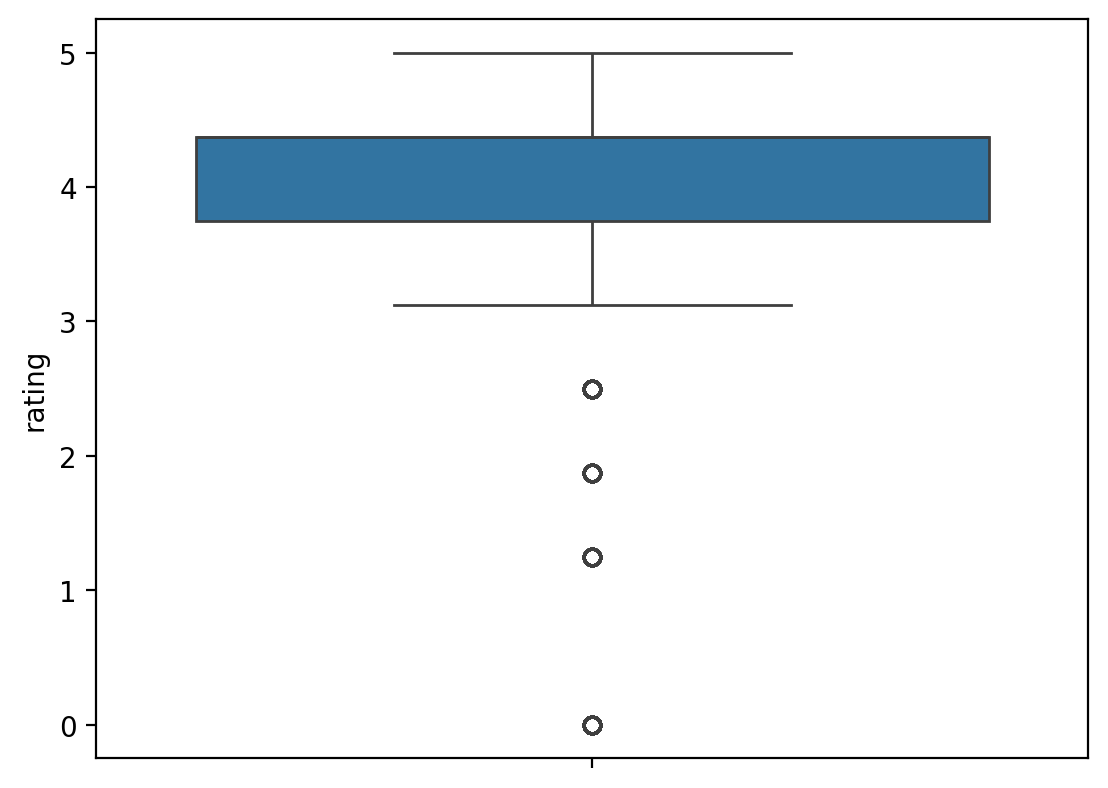

In [11]:
sns.boxplot(df_ingr["rating"])

In [12]:
len(df_ingr["rating"].sort_values().unique())

8

В ходе исследования было выявленно, что рейтинг не является непрерывной последотвательностью, а имеет только 8 уникальных значений, в следствии чего можно сделать выводы что решение предложенной задачи лежит в рамках задачи классификации, а не регрессии

## 2. Train test split

In [13]:
X=df_ingr.drop(columns=rating+pit_vesh)
y=df_ingr["rating"]

In [14]:
X

,almond,amaretto,anchovy,anise,apple,apple juice,apricot,artichoke,arugula,asian pear,...,watermelon,whiskey,white wine,whole wheat,wild rice,wine,yellow squash,yogurt,yuca,zucchini
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18130,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18131,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18132,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18133,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,random_state=21,test_size=0.2,shuffle=True)

<Axes: xlabel='rating', ylabel='Count'>

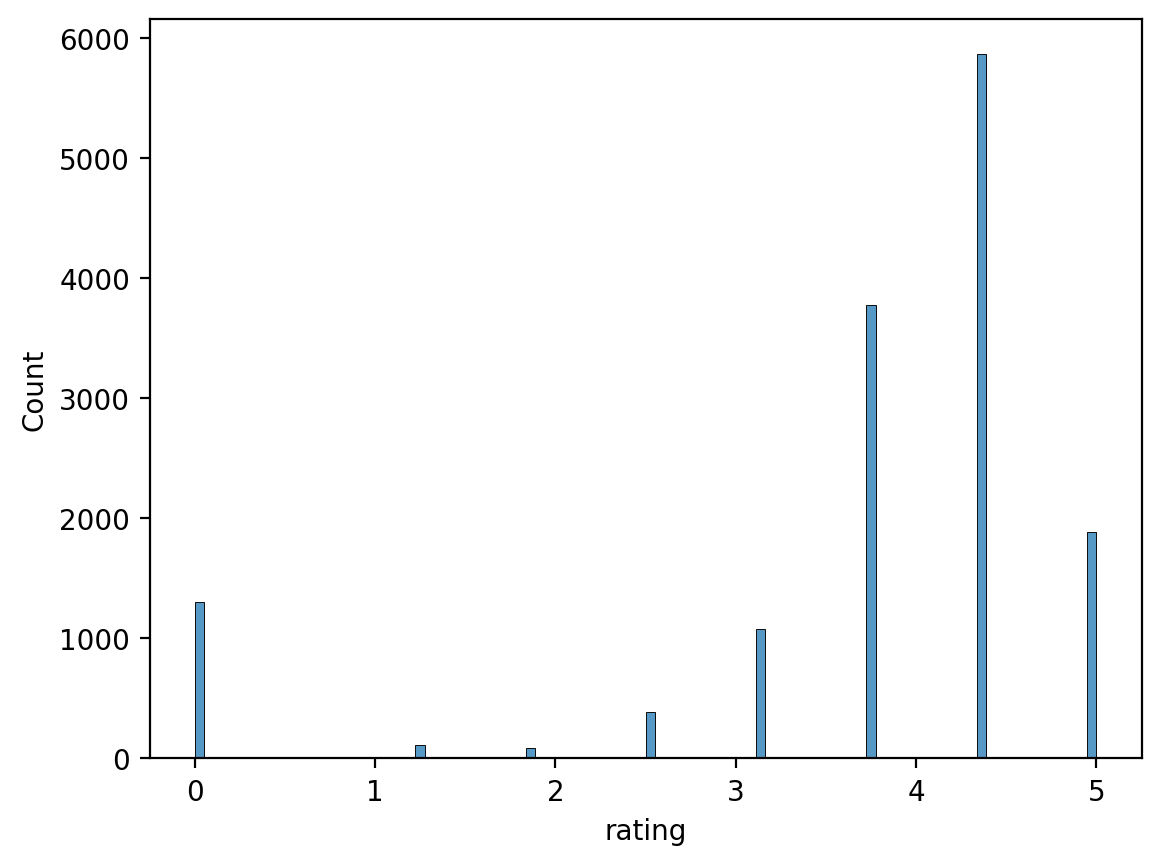

In [16]:
sns.histplot(y_train)

<Axes: xlabel='rating', ylabel='Count'>

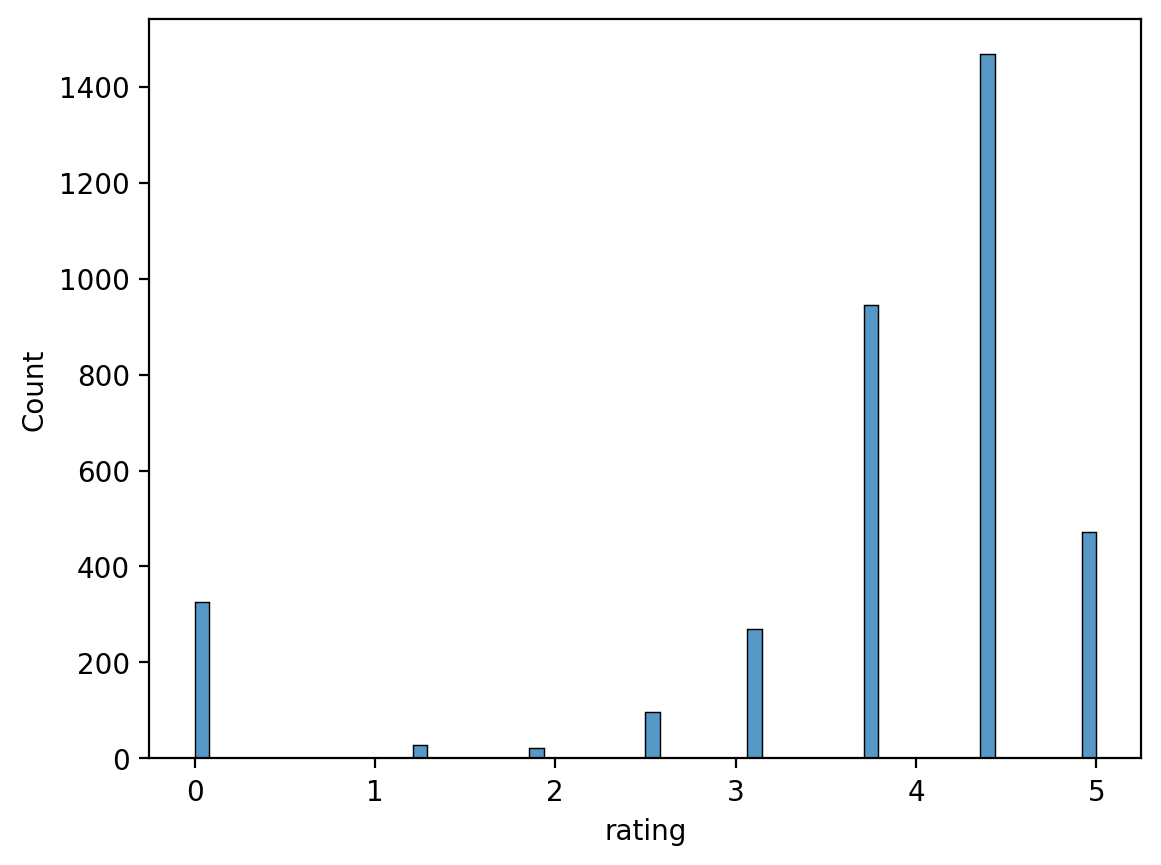

In [17]:
sns.histplot(y_test)

При визуализации распределения данных замечен сильный дисбаланс значений

# Класс обработки данных

In [ ]:
class DateParse:
    def __init__(self,path_date):
        self.path_date=path_date
        self.df=pd.read_csv(path_date)
        self._ingredients = [
    'almond',
    'amaretto',
    'anchovy',
    'anise',
    'apple',
    'apple juice',
    'apricot',
    'artichoke',
    'arugula',
    'asian pear',
    'asparagus',
    'avocado',
    'bacon',
    'banana',
    'barley',
    'basil',
    'bass',
    'bean',
    'beef',
    'beef rib',
    'beef shank',
    'beef tenderloin',
    'beer',
    'beet',
    'bell pepper',
    'berry',
    'bitters',
    'blackberry',
    'blue cheese',
    'blueberry',
    'bok choy',
    'bourbon',
    'bran',
    'brandy',
    'bread',
    'breadcrumbs',
    'brie',
    'brisket',
    'broccoli',
    'broccoli rabe',
    'brown rice',
    'brownie',
    'brussel sprout',
    'bulgur',
    'butter',
    'buttermilk',
    'butternut squash',
    'butterscotch/caramel',
    'cabbage',
    'cake',
    'calvados',
    'campari',
    'candy',
    'cantaloupe',
    'capers',
    'caraway',
    'cardamom',
    'carrot',
    'cashew',
    'cauliflower',
    'caviar',
    'celery',
    'chambord',
    'champagne',
    'chard',
    'chartreuse',
    'cheddar',
    'cheese',
    'cherry',
    'chestnut',
    'chicken',
    'chickpea',
    'chile',
    'chile pepper',
    'chili',
    'chive',
    'chocolate',
    'cilantro',
    'cinnamon',
    'citrus',
    'clam',
    'clove',
    'coconut',
    'cod',
    'coffee',
    'cognac/armagnac',
    'collard greens',
    'condiment/spread',
    'cookie',
    'cookies',
    'coriander',
    'corn',
    'cornmeal',
    'cottage cheese',
    'couscous',
    'crab',
    'cranberry',
    'cranberry sauce',
    'cream cheese',
    'créme de cacao',
    'cr��me de cacao',
    'cucumber',
    'cumin',
    'cupcake',
    'currant',
    'curry',
    'custard',
    'date',
    'dill',
    'duck',
    'eau de vie',
    'egg',
    'egg nog',
    'eggplant',
    'endive',
    'escarole',
    'fennel',
    'feta',
    'fig',
    'fish',
    'flat bread',
    'fontina',
    'fortified wine',
    'frangelico',
    'fruit juice',
    'game',
    'garlic',
    'gin',
    'ginger',
    'goat cheese',
    'goose',
    'gouda',
    'grand marnier',
    'granola',
    'grape',
    'grapefruit',
    'grappa',
    'green bean',
    'green onion/scallion',
    'ground beef',
    'ground lamb',
    'guava',
    'halibut',
    'ham',
    'hazelnut',
    'herb',
    'hominy/cornmeal/masa',
    'honey',
    'honeydew',
    'horseradish',
    'hot pepper',
    'hummus',
    'ice cream',
    'jalapeño',
    'jam or jelly',
    'jícama',
    'kahlúa',
    'kale',
    'kirsch',
    'kiwi',
    'kumquat',
    'lamb',
    'lamb chop',
    'lamb shank',
    'leafy green',
    'leek',
    'legume',
    'lemon',
    'lemon juice',
    'lemongrass',
    'lentil',
    'lettuce',
    'lima bean',
    'lime',
    'lime juice',
    'lingonberry',
    'liqueur',
    'lobster',
    'lychee',
    'macadamia nut',
    'mango',
    'maple syrup',
    'marscarpone',
    'marshmallow',
    'mayonnaise',
    'meat',
    'melon',
    'mezcal',
    'midori',
    'milk/cream',
    'mint',
    'molasses',
    'monterey jack',
    'mozzarella',
    'muffin',
    'mushroom',
    'mussel',
    'mustard',
    'mustard greens',
    'nectarine',
    'noodle',
    'nut',
    'nutmeg',
    'oat',
    'oatmeal',
    'octopus',
    'okra',
    'olive',
    'onion',
    'orange',
    'orange juice',
    'oregano',
    'orzo',
    'oyster',
    'pancake',
    'papaya',
    'paprika',
    'parmesan',
    'parsley',
    'parsnip',
    'passion fruit',
    'pasta',
    'pea',
    'peach',
    'peanut',
    'peanut butter',
    'pear',
    'pecan',
    'pepper',
    'pernod',
    'persimmon',
    'phyllo/puff pastry dough',
    'pickles',
    'pie',
    'pine nut',
    'pineapple',
    'pistachio',
    'pizza',
    'plantain',
    'plum',
    'poblano',
    'pomegranate',
    'pomegranate juice',
    'poppy',
    'pork',
    'pork chop',
    'pork rib',
    'pork tenderloin',
    'port',
    'potato',
    'poultry',
    'poultry sausage',
    'prosciutto',
    'prune',
    'pumpkin',
    'quail',
    'quince',
    'quinoa',
    'rabbit',
    'rack of lamb',
    'radicchio',
    'radish',
    'raisin',
    'raspberry',
    'red wine',
    'rhubarb',
    'rice',
    'ricotta',
    'root vegetable',
    'rosemary',
    'rosé',
    'rum',
    'rutabaga',
    'rye',
    'saffron',
    'sage',
    'sake',
    'salmon',
    'salsa',
    'sardine',
    'sauce',
    'sausage',
    'scallop',
    'scotch',
    'seafood',
    'seed',
    'semolina',
    'sesame',
    'sesame oil',
    'shallot',
    'shellfish',
    'sherry',
    'shrimp',
    'snapper',
    'sorbet',
    'sour cream',
    'sourdough',
    'soy',
    'soy sauce',
    'sparkling wine',
    'spice',
    'spinach',
    'spirit',
    'squash',
    'squid',
    'steak',
    'strawberry',
    'stuffing/dressing',
    'sugar snap pea',
    'sweet potato/yam',
    'swiss cheese',
    'swordfish',
    'tamarind',
    'tangerine',
    'tapioca',
    'tarragon',
    'tea',
    'tequila',
    'thyme',
    'tilapia',
    'tofu',
    'tomatillo',
    'tomato',
    'tortillas',
    'triple sec',
    'tropical fruit',
    'trout',
    'tuna',
    'turnip',
    'vanilla',
    'veal',
    'vegetable',
    'venison',
    'vermouth',
    'vinegar',
    'vodka',
    'waffle',
    'walnut',
    'wasabi',
    'watercress',
    'watermelon',
    'whiskey',
    'white wine',
    'whole wheat',
    'wild rice',
    'wine',
    'yellow squash',
    'yogurt',
    'yuca',
    'zucchini',

]
        self._pit_vesh=[
            'calories',
            'protein',
            'fat',
            'sodium'
        ],
        self._rating=["rating"]
    def parsing(self):
        self.df=self.df[self._ingredients+self._rating].drop_duplicates().reset_index(drop=True)
        return self.df
    def only_ingr(self):
        return self.df.drop(columns=self._rating)
    def train_test_split(self):
        self.parsing()
        X=df_ingr.drop(columns=self._rating+self._pit_vesh)
        y=df_ingr[self._rating]
        X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,random_state=21,test_size=0.2,shuffle=True)
        return X_train,X_test,y_train,y_test

## 3. Models

In [18]:
from sklearn.metrics import root_mean_squared_error


# Linear Regression

In [22]:
param_grid = {
    'fit_intercept': [True, False],
    'positive': [False, True]
}

In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
ln=LinearRegression()
grid_line=GridSearchCV(ln,param_grid=param_grid,cv=5,n_jobs=-1)
grid_line.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'fit_intercept': [True, False], 'positive': [False, True]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold a

In [26]:
pred_line=grid_line.predict(X_test)

In [27]:
root_mean_squared_error(y_test,pred_line)

1.2702687224653904

<Axes: ylabel='Count'>

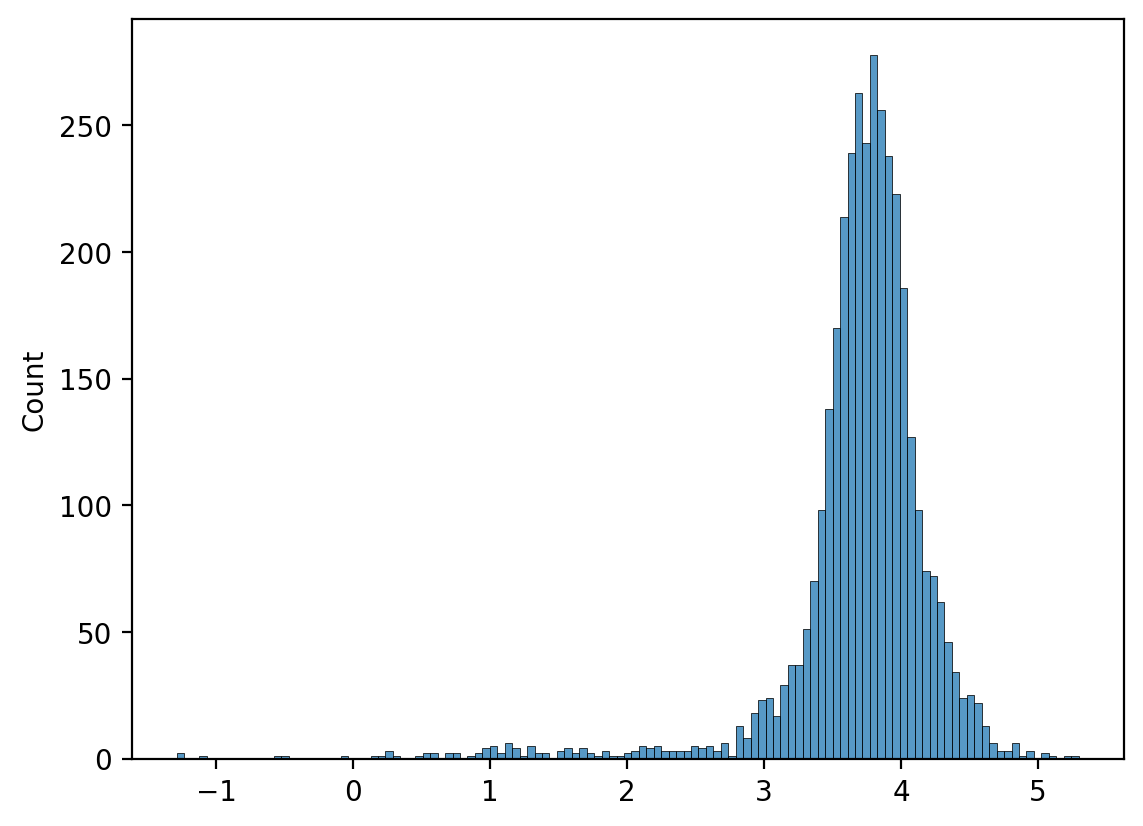

In [28]:
sns.histplot(pred_line)

# SVM

In [29]:
params={
    "C":[1,10,50],
    "kernel":["poly","rbf","sigmoid"],
    "gamma":[0.01,0.1,1],
    "degree":[2,3,4,5],

}

In [30]:
from sklearn.svm import SVR

In [31]:
svm=SVR()

In [32]:
grid=GridSearchCV(svm,param_grid=params,scoring="neg_root_mean_squared_error",cv=5,n_jobs=-1)

In [33]:
train_x,test_x,train_y,test_t=train_test_split(X_train,y_train,stratify=y_train,random_state=21,test_size=0.6,shuffle=True)

In [34]:
train_x

,almond,amaretto,anchovy,anise,apple,apple juice,apricot,artichoke,arugula,asian pear,...,watermelon,whiskey,white wine,whole wheat,wild rice,wine,yellow squash,yogurt,yuca,zucchini
8227,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7502,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9753,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4904,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5023,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6383,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17423,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12864,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3889,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: xlabel='rating', ylabel='Count'>

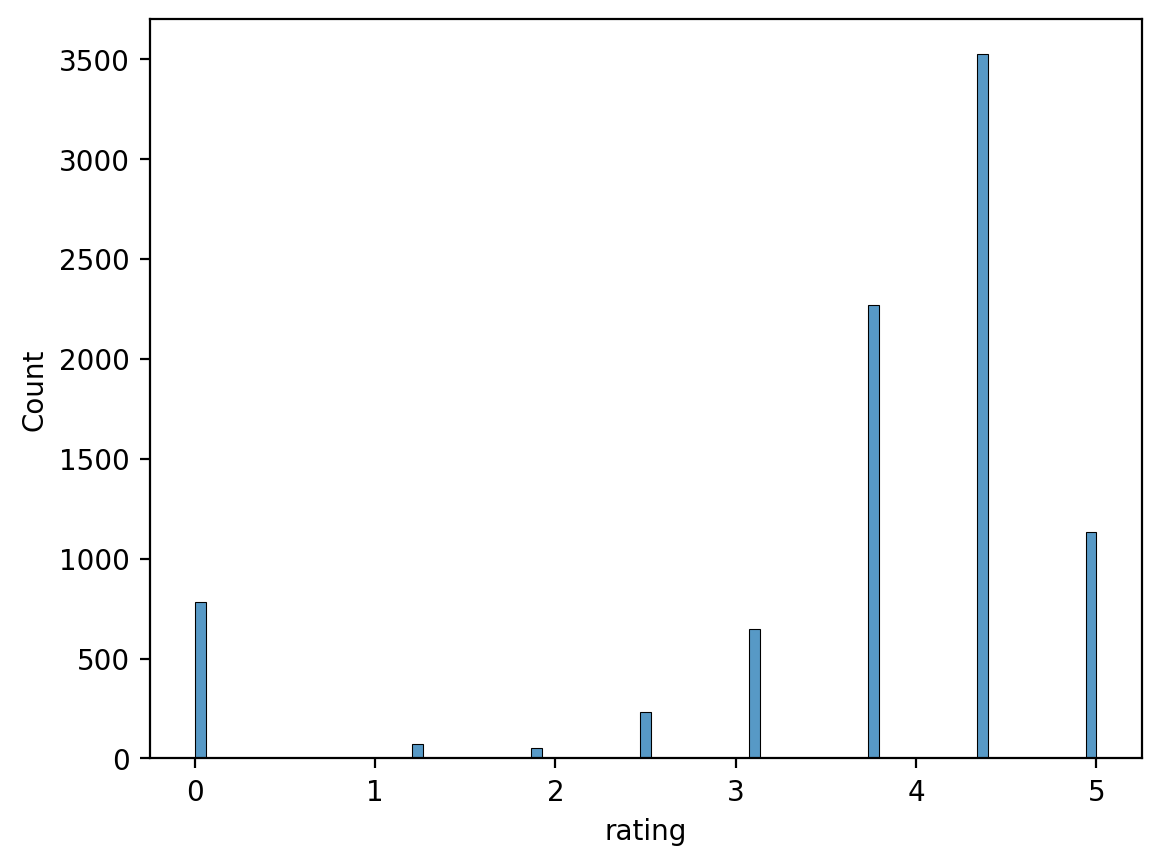

In [35]:
sns.histplot(test_t)

<Axes: xlabel='rating', ylabel='Count'>

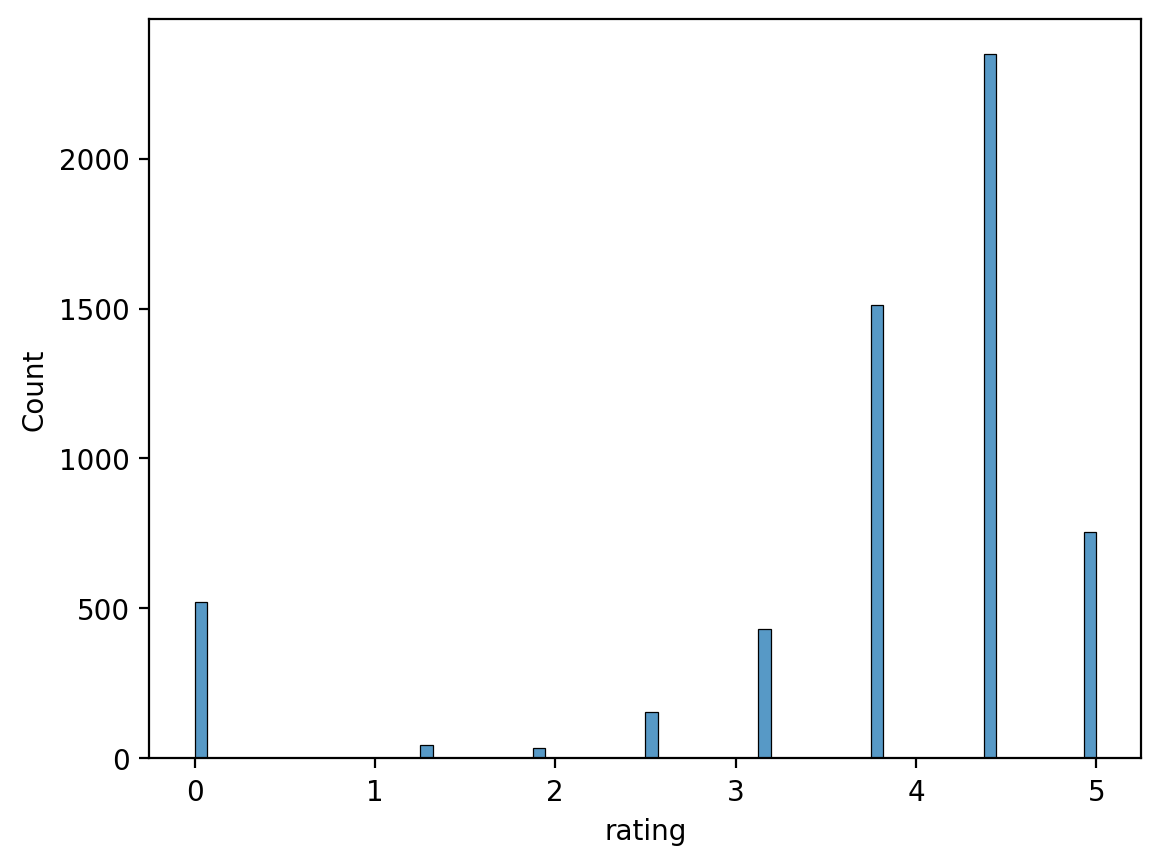

In [36]:
sns.histplot(train_y)

In [37]:
from sklearn.discriminant_analysis import StandardScaler


standrd=StandardScaler().set_output(transform="pandas")
std_t=standrd.fit_transform(train_x,train_y)

In [38]:
std_t

,almond,amaretto,anchovy,anise,apple,apple juice,apricot,artichoke,arugula,asian pear,...,watermelon,whiskey,white wine,whole wheat,wild rice,wine,yellow squash,yogurt,yuca,zucchini
8227,-0.165646,-0.039409,-0.04738,-0.075619,-0.185960,-0.018566,-0.116714,-0.094154,-0.124078,-0.026261,...,-0.052577,-0.061684,-0.153731,-0.034749,-0.039409,-0.097810,-0.043576,-0.165646,-0.013127,-0.128306
7502,-0.165646,-0.039409,-0.04738,-0.075619,-0.185960,-0.018566,-0.116714,-0.094154,-0.124078,-0.026261,...,-0.052577,-0.061684,-0.153731,-0.034749,-0.039409,10.223858,-0.043576,-0.165646,-0.013127,-0.128306
9753,-0.165646,-0.039409,-0.04738,-0.075619,-0.185960,-0.018566,-0.116714,-0.094154,-0.124078,-0.026261,...,-0.052577,-0.061684,-0.153731,-0.034749,-0.039409,-0.097810,-0.043576,-0.165646,-0.013127,-0.128306
4904,-0.165646,-0.039409,-0.04738,-0.075619,-0.185960,-0.018566,-0.116714,-0.094154,-0.124078,-0.026261,...,-0.052577,-0.061684,-0.153731,-0.034749,-0.039409,-0.097810,-0.043576,-0.165646,-0.013127,-0.128306
5023,-0.165646,-0.039409,-0.04738,-0.075619,-0.185960,-0.018566,-0.116714,-0.094154,-0.124078,-0.026261,...,19.019727,-0.061684,-0.153731,-0.034749,-0.039409,-0.097810,-0.043576,-0.165646,-0.013127,-0.128306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6383,-0.165646,-0.039409,-0.04738,-0.075619,-0.185960,-0.018566,-0.116714,-0.094154,-0.124078,-0.026261,...,-0.052577,-0.061684,-0.153731,-0.034749,-0.039409,-0.097810,-0.043576,-0.165646,-0.013127,-0.128306
17423,-0.165646,-0.039409,-0.04738,-0.075619,-0.185960,-0.018566,-0.116714,-0.094154,-0.124078,-0.026261,...,-0.052577,-0.061684,-0.153731,-0.034749,-0.039409,-0.097810,-0.043576,-0.165646,-0.013127,-0.128306
12864,-0.165646,-0.039409,-0.04738,-0.075619,-0.185960,-0.018566,-0.116714,-0.094154,-0.124078,-0.026261,...,-0.052577,-0.061684,-0.153731,-0.034749,-0.039409,-0.097810,-0.043576,-0.165646,-0.013127,-0.128306
3889,-0.165646,-0.039409,-0.04738,-0.075619,-0.185960,-0.018566,-0.116714,-0.094154,-0.124078,-0.026261,...,-0.052577,-0.061684,-0.153731,-0.034749,-0.039409,-0.097810,-0.043576,-0.165646,-0.013127,-0.128306


In [39]:
#grid.fit(train_x,train_y)

In [40]:
#grid.best_params_

Best params for SVM {'C': 1, 'degree': 2, 'gamma': 0.1, 'kernel': 'rbf'}

In [41]:
root_mean_squared_error(y_test,grid.predict(X_test))

NotFittedError: This GridSearchCV instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [28]:
svm=SVR(**{'C': 1, 'degree': 2, 'gamma': 0.1, 'kernel': 'rbf'})

In [29]:
svm.fit(X_train,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",2
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [44]:
y_train.sort_values().unique()

array([0.   , 1.25 , 1.875, 2.5  , 3.125, 3.75 , 4.375, 5.   ])

In [45]:
pred_svm=svm.predict(X_test)

In [46]:
root_mean_squared_error(y_test,pred_svm)

1.3075373330592022

In [47]:
y_train.describe()

count    14512.000000
mean         3.717742
std          1.328673
min          0.000000
25%          3.750000
50%          4.375000
75%          4.375000
max          5.000000
Name: rating, dtype: float64

<Axes: xlabel='rating', ylabel='Count'>

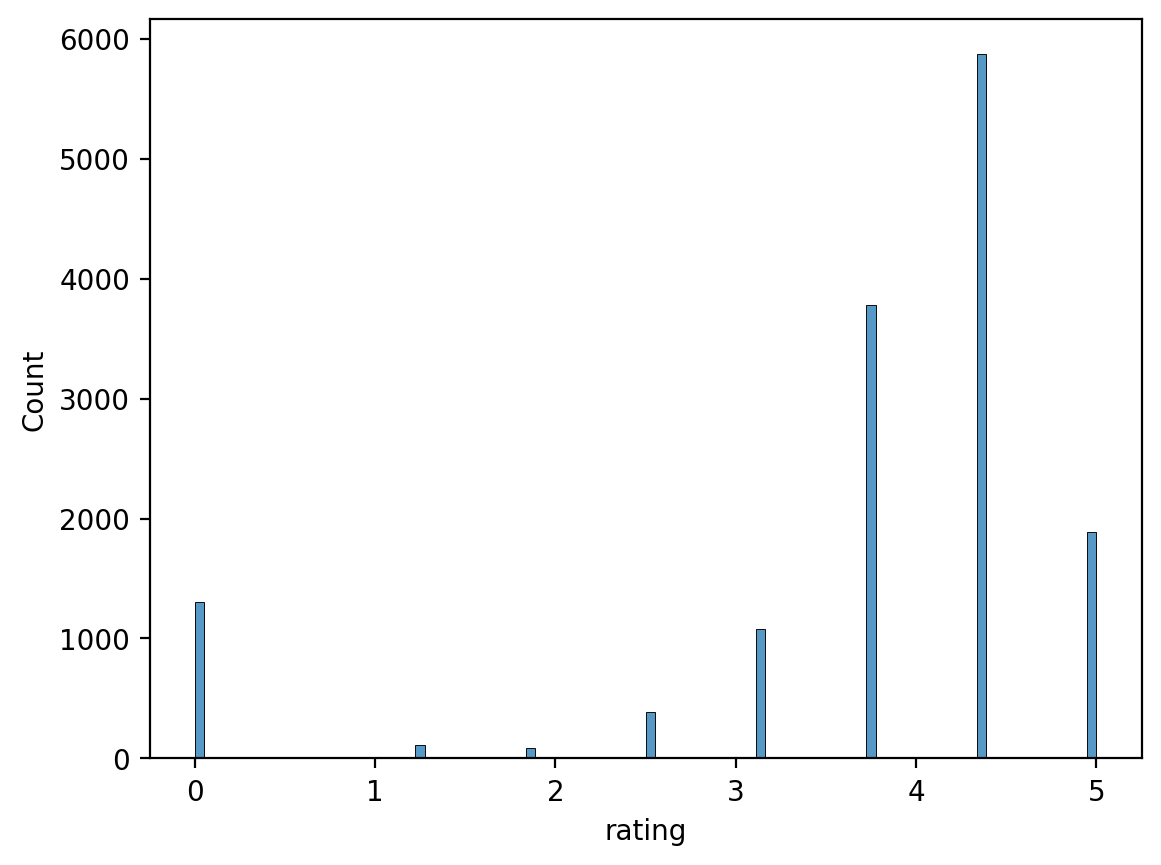

In [48]:
sns.histplot(y_train)

<Axes: xlabel='rating', ylabel='Count'>

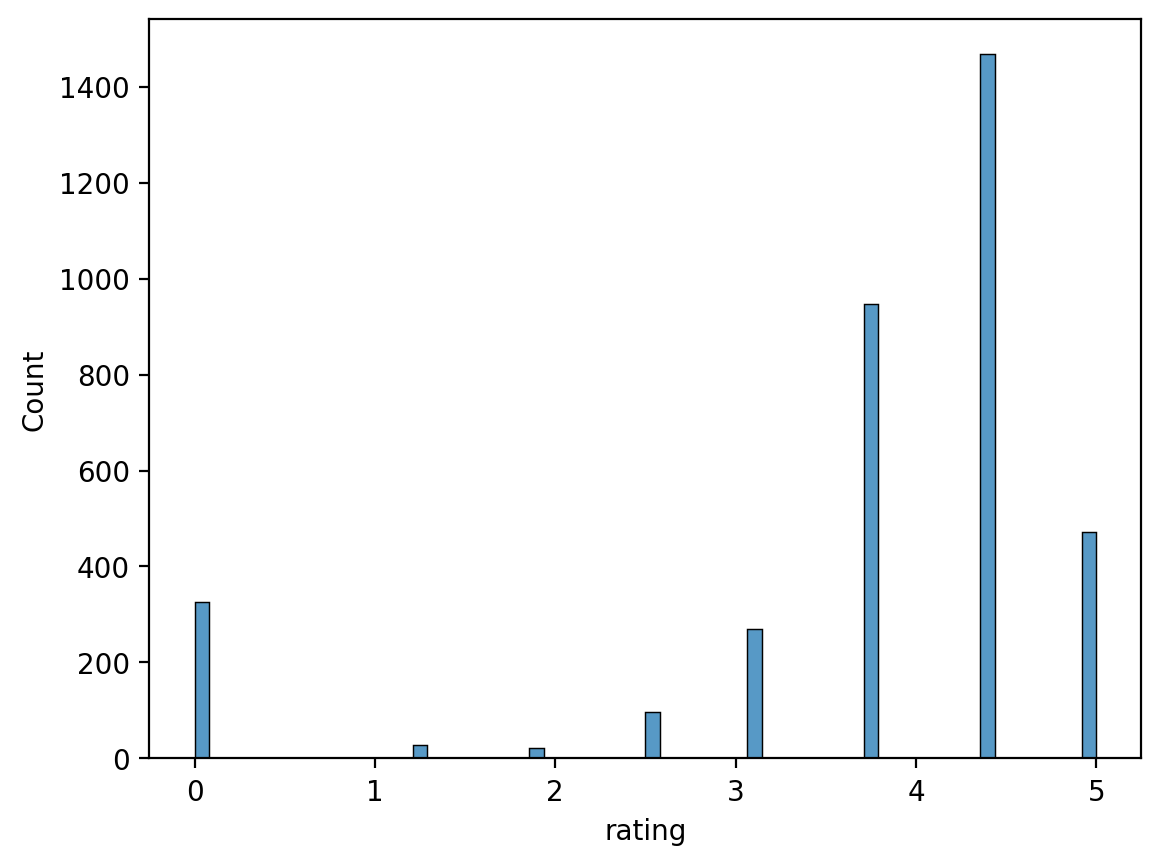

In [49]:
sns.histplot(y_test)

<Axes: ylabel='Count'>

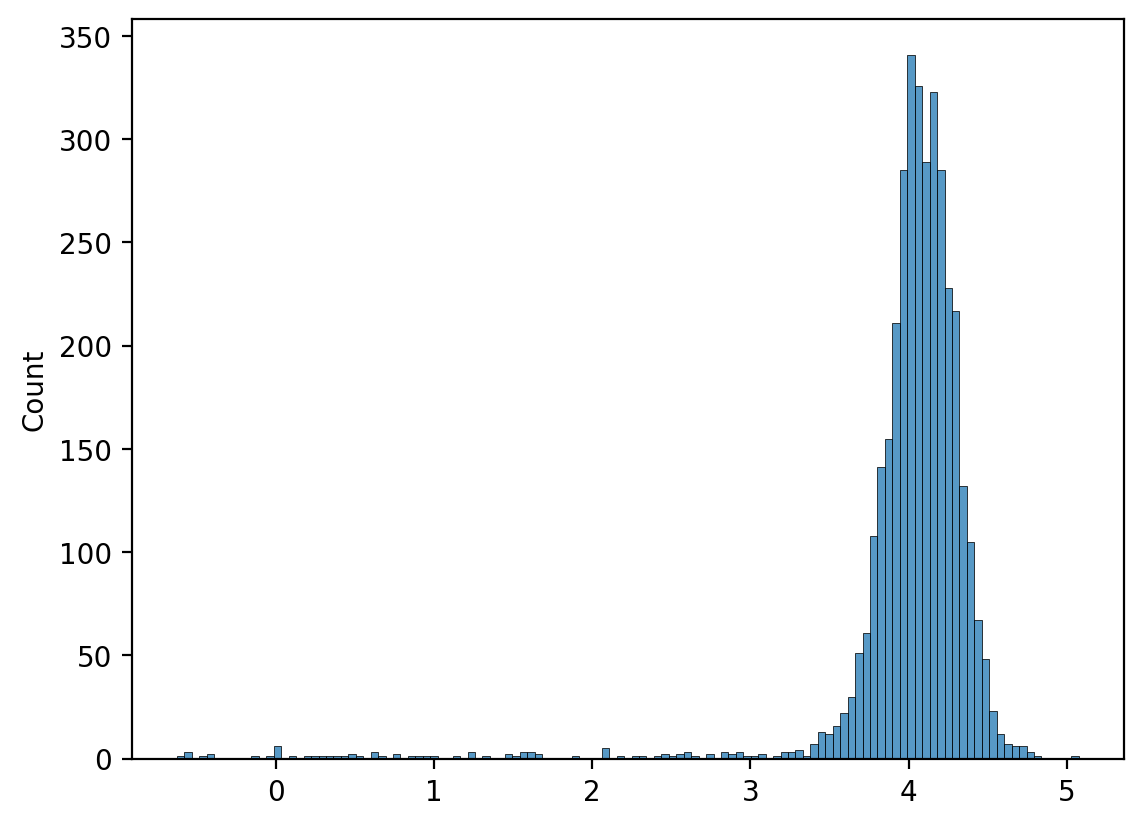

In [50]:
sns.histplot(pred_svm)

Неудовлетворительно

# Random Forest

In [51]:
from sklearn.ensemble import RandomForestRegressor

In [52]:
rfr=RandomForestRegressor(max_depth=2,random_state=21)
rfr.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [53]:
root_mean_squared_error(train_y,rfr.predict(train_x))

1.2878798768650097

In [54]:
root_mean_squared_error(test_t,rfr.predict(test_x))

1.2939130448641958

In [55]:
params_rdf={
    "n_estimators":[50,100,200,300],
    "max_depth":list(range(2,9)),
    "min_samples_split":[2,3,4,5,8],
    "max_features":[100,200,300,351],
    "bootstrap":[False,True],
    "n_jobs":[-1],
    "random_state":[21]
}

In [56]:
rdf=RandomForestRegressor()
grid_rdf=GridSearchCV(rdf,param_grid=params_rdf,n_jobs=-1)

In [57]:
#grid_rdf.fit(train_x,train_y)

Лучшая модель для случайного леса

GridSearchCV
?i

best_estimator_: RandomForestRegressor
RandomForestRegressor(max_depth=8, max_features=100, n_estimators=50, n_jobs=-1,
                      random_state=21)

In [58]:
root_mean_squared_error(grid_rdf.predict(test_x),test_t)

NotFittedError: This GridSearchCV instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

Обучим лучшую модель на всей выборке

In [32]:
rdf=RandomForestRegressor(max_depth=8, max_features=100, n_estimators=50, n_jobs=-1,
                      random_state=21)
rdf.fit(X_train,y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",100
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

In [61]:
pred_rdf=rdf.predict(X_test)

In [62]:
Q1=np.quantile(pred_rdf,0.25)
Q3=np.quantile(pred_rdf,0.75)
iqr=Q3-Q1

In [63]:
clear_pred_rdf=pd.DataFrame(pred_rdf,columns=["pred"])

In [64]:
clear_pred_rdf[clear_pred_rdf["pred"].between(Q1 - 1.5 * iqr, Q3 + 1.5 * iqr)]

,pred
0,3.784344
2,3.784344
3,3.784344
4,3.784344
8,3.784344
...,...
3623,3.784344
3624,3.784344
3625,3.784344
3626,3.784344


In [65]:
clear_pred_rdf["pred"]

0       3.784344
1       3.824774
2       3.784344
3       3.784344
4       3.784344
          ...   
3623    3.784344
3624    3.784344
3625    3.784344
3626    3.784344
3627    3.784344
Name: pred, Length: 3628, dtype: float64

In [66]:
clear_pred_rdf_c = clear_pred_rdf[clear_pred_rdf["pred"].between(Q1 - 1.5 * iqr, Q3 + 1.5 * iqr)]

In [67]:
clear_pred_rdf_c

,pred
0,3.784344
2,3.784344
3,3.784344
4,3.784344
8,3.784344
...,...
3623,3.784344
3624,3.784344
3625,3.784344
3626,3.784344


In [68]:
clear_pred_rdf_c.min()

pred    3.784344
dtype: float64

<Axes: >

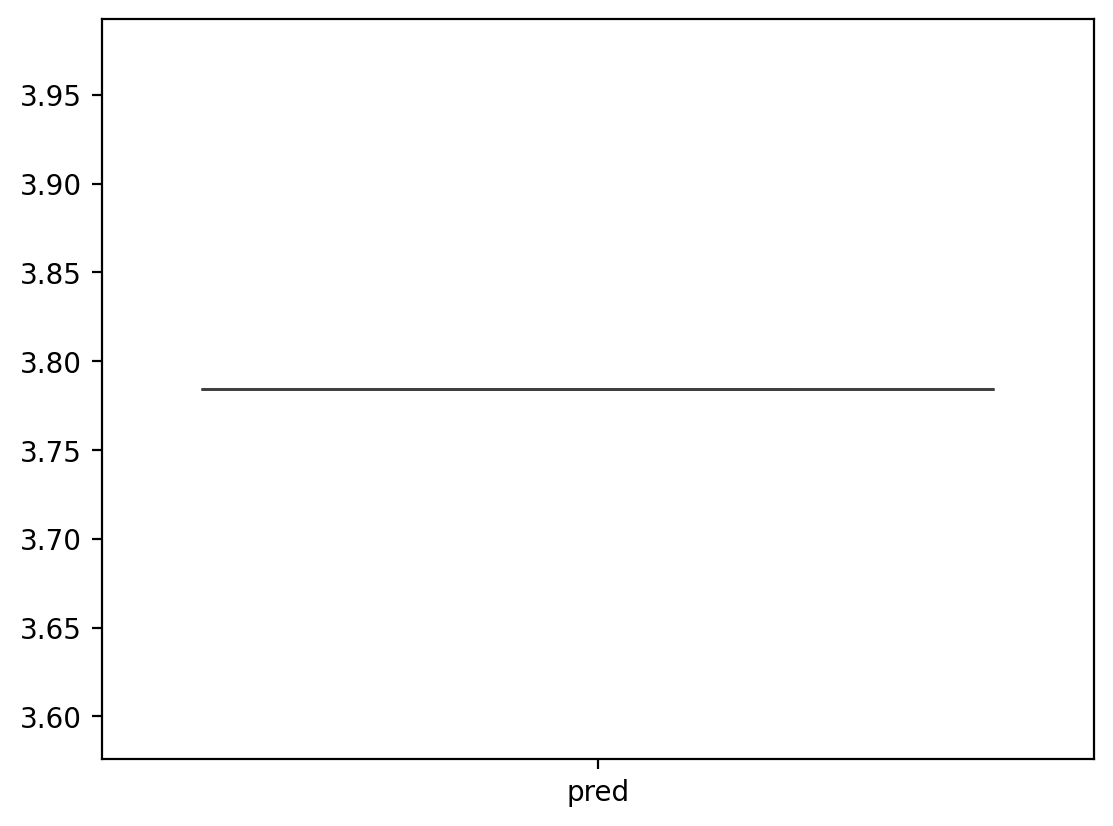

In [69]:
sns.boxplot(clear_pred_rdf_c)

<Axes: ylabel='Count'>

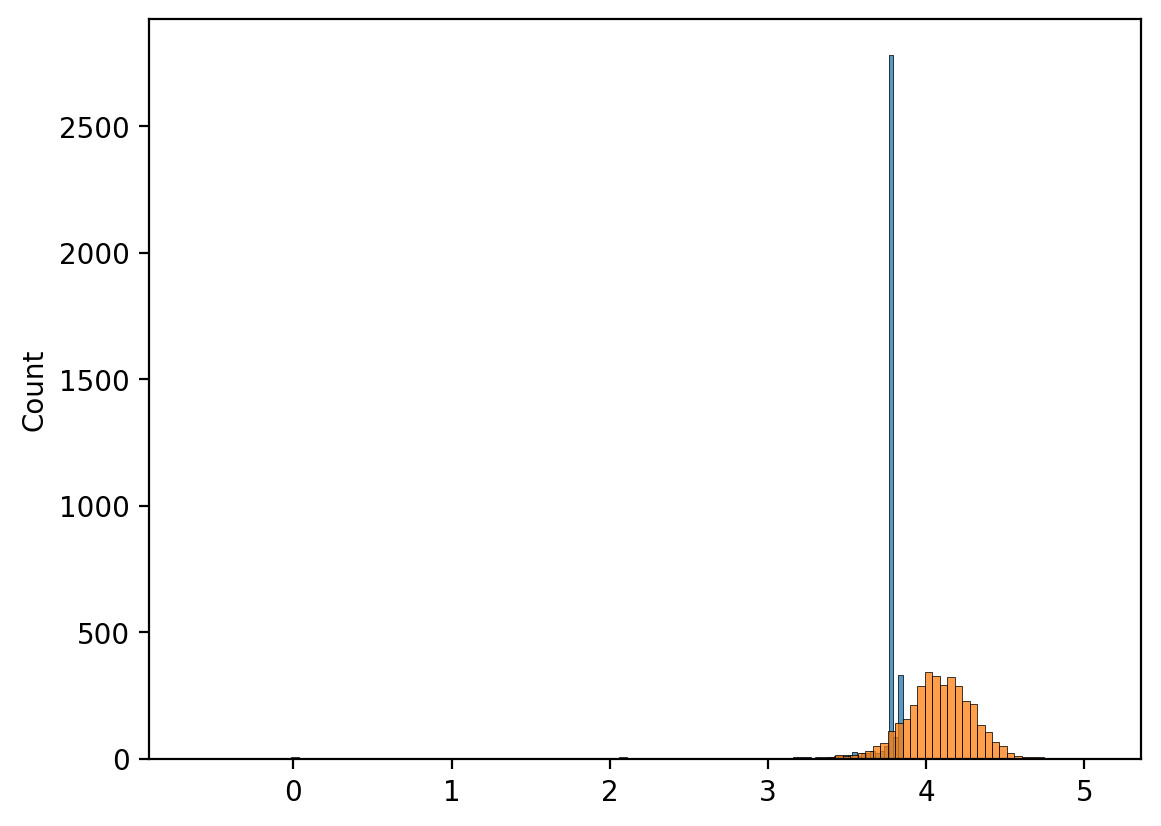

In [70]:
sns.histplot(rdf.predict(X_test))
sns.histplot(pred_svm)

In [71]:
y_test[0:10]

10282    4.375
8057     4.375
17335    3.125
14517    4.375
13223    3.750
10603    0.000
13798    4.375
2759     4.375
10690    4.375
9538     0.000
Name: rating, dtype: float64

In [72]:
root_mean_squared_error(rdf.predict(X_test),y_test)

1.2686683858693095

In [73]:
root_mean_squared_error(rdf.predict(X_train),y_train)

1.250718760322912

Отклонение стало чуть меньше

Результаты неудовлетворительны, среднее отклонение от действительного значения очень большое

По результатам моделей регрессии видно, что они пытаются работать в рамках непрерывных значений, в то время как целевая переменная имеет вид классов

Кросс валидация для лучших моделей

Ансамбли

In [ ]:
vot_reg=VotingRegressor(estimators=[("lr",ln),("svr",svm),("rdf",rdf)])
vot_reg.fit(X_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('svr', ...), ...]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",2


In [75]:
pred_vot=vot_reg.predict(X_test)
root_mean_squared_error(pred_vot,y_test)

1.260440431507297

<Axes: ylabel='Count'>

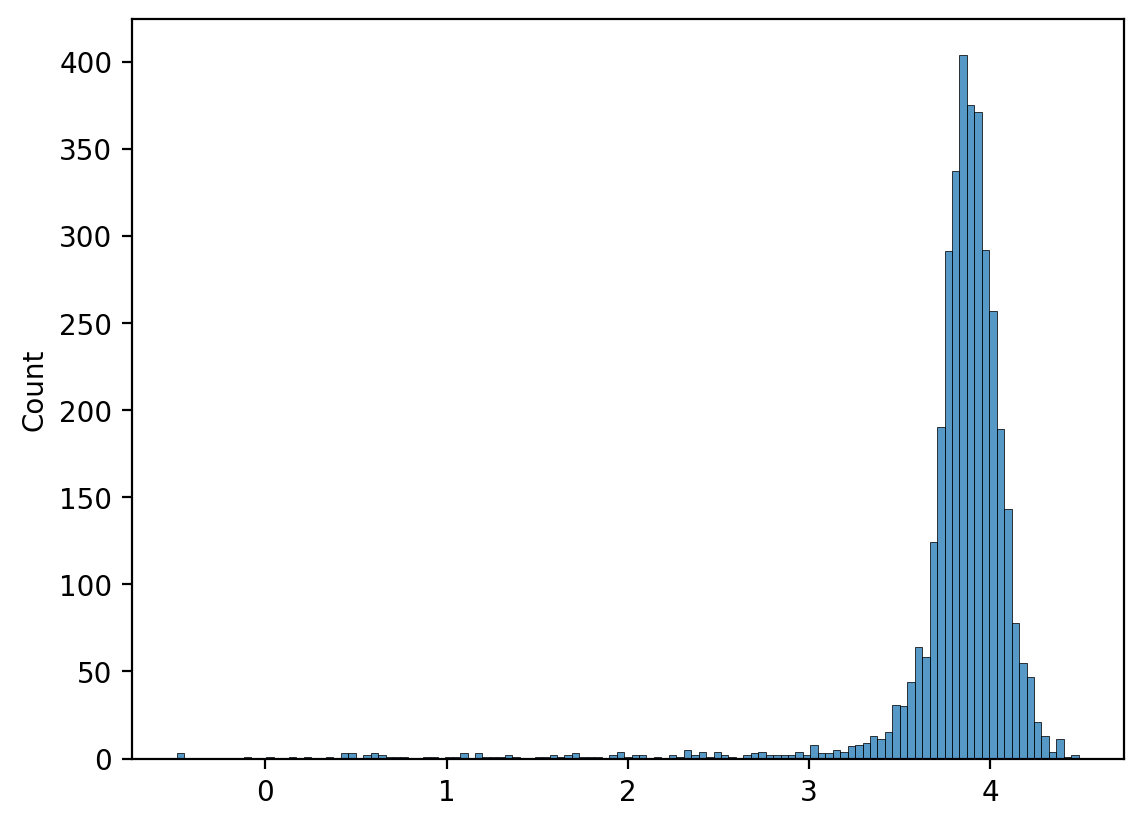

In [76]:
sns.histplot(pred_vot)

In [82]:
cross_val_score(rdf,X,y,scoring="neg_root_mean_squared_error")

array([-1.2806384 , -1.25582285, -1.26324957, -1.27564183, -1.30595042])

In [83]:
cross_val_score(vot_reg,X,y,scoring="neg_root_mean_squared_error")

array([-1.26834205, -1.24148642, -1.25367541, -1.26718797, -1.29274322])

In [34]:
from sklearn.ensemble import StackingRegressor


stack_reg=StackingRegressor(estimators=[("lr",ln),("svr",svm),("rdf",rdf)])
stack_reg.fit(X_train,y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('lr', ...), ('svr', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",None
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`.

In [35]:
root_mean_squared_error(stack_reg.predict(X_test),y_test)

1.2687578219567652

Регрессионные методы не показали удовлетворительных результатов, в следствии чего будем рассматривать задачу, как задачу классификации

# Классификация

In [40]:
np.round(y_train.unique())

array([5., 3., 4., 0., 2., 4., 1., 2.])

In [41]:
df_ingr["rating_round"]=np.round(df_ingr["rating"])

/tmp/ipykernel_6131/594227756.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ingr["rating_round"]=np.round(df_ingr["rating"])


In [42]:
X=df_ingr.drop(columns=["rating","rating_round"]+pit_vesh)
y=df_ingr["rating_round"]

<Axes: xlabel='rating_round', ylabel='Count'>

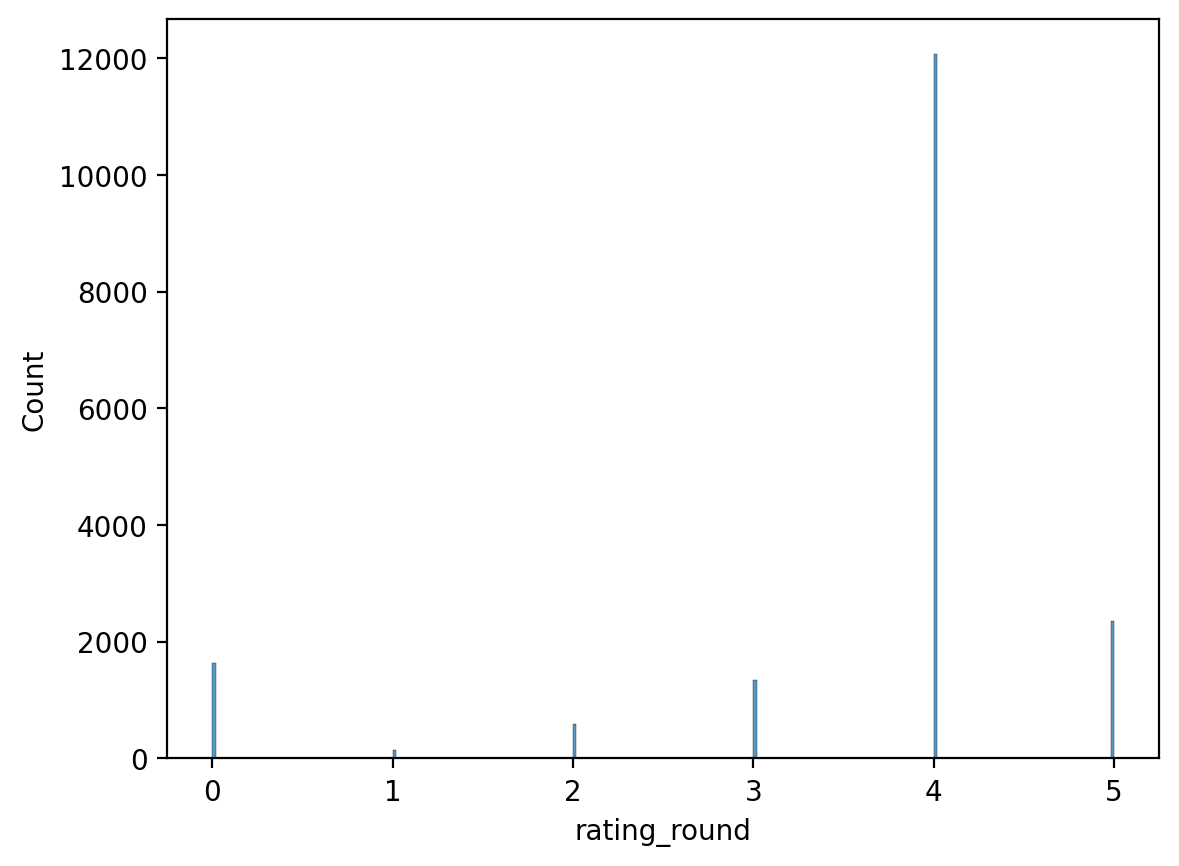

In [43]:
sns.histplot(y)

In [44]:
X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,random_state=21,test_size=0.2,shuffle=True)

In [45]:
X

,almond,amaretto,anchovy,anise,apple,apple juice,apricot,artichoke,arugula,asian pear,...,watermelon,whiskey,white wine,whole wheat,wild rice,wine,yellow squash,yogurt,yuca,zucchini
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18130,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18131,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18132,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18133,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


LogReg

In [20]:
param_grid = {
    'C': np.logspace(-2, 4, 10),           # обратная сила регуляризации (чем меньше C, тем сильнее регуляризация)
    'penalty': [ 'l2', None],
    'solver': ['sag'],                      # saga поддерживает все типы penalty
    'l1_ratio': np.linspace(0, 1, 5),         # для elasticnet (доля L1)
    'class_weight': [None, 'balanced'],
    'max_iter': [500, 1000],            # для сходимости
    'fit_intercept': [True]
}

In [23]:
from sklearn.model_selection import RandomizedSearchCV

In [27]:
log_reg=LogisticRegression()
random_search = RandomizedSearchCV(
    log_reg,
    param_distributions=param_grid,
    n_iter=10,  
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=None)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_V

[CV] END C=21.54434690031882, class_weight=None, fit_intercept=True, l1_ratio=0.5, max_iter=500, penalty=None, solver=sag; total time=  32.1s
[CV] END C=464.1588833612773, class_weight=None, fit_intercept=True, l1_ratio=0.0, max_iter=500, penalty=l2, solver=sag; total time=  31.6s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=None)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_V

[CV] END C=464.1588833612773, class_weight=None, fit_intercept=True, l1_ratio=0.0, max_iter=500, penalty=l2, solver=sag; total time=  32.9s
[CV] END C=21.54434690031882, class_weight=None, fit_intercept=True, l1_ratio=0.5, max_iter=500, penalty=None, solver=sag; total time=  33.5s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_V

[CV] END C=21.54434690031882, class_weight=None, fit_intercept=True, l1_ratio=0.5, max_iter=500, penalty=None, solver=sag; total time=  33.5s
[CV] END C=464.1588833612773, class_weight=None, fit_intercept=True, l1_ratio=0.0, max_iter=500, penalty=l2, solver=sag; total time=  33.0s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=0.5. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/

[CV] END C=21.54434690031882, class_weight=None, fit_intercept=True, l1_ratio=0.5, max_iter=500, penalty=None, solver=sag; total time=  34.2s
[CV] END C=21.54434690031882, class_weight=None, fit_intercept=True, l1_ratio=0.5, max_iter=500, penalty=None, solver=sag; total time=  33.9s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_V

[CV] END C=464.1588833612773, class_weight=None, fit_intercept=True, l1_ratio=0.0, max_iter=500, penalty=l2, solver=sag; total time=  33.9s
[CV] END C=464.1588833612773, class_weight=None, fit_intercept=True, l1_ratio=0.0, max_iter=500, penalty=l2, solver=sag; total time=  33.6s
[CV] END C=0.01, class_weight=balanced, fit_intercept=True, l1_ratio=0.75, max_iter=500, penalty=None, solver=sag; total time=  33.8s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=None)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_V

[CV] END C=0.01, class_weight=balanced, fit_intercept=True, l1_ratio=0.75, max_iter=500, penalty=None, solver=sag; total time=  34.2s
[CV] END C=21.54434690031882, class_weight=None, fit_intercept=True, l1_ratio=0.5, max_iter=1000, penalty=l2, solver=sag; total time=  11.8s
[CV] END C=21.54434690031882, class_weight=None, fit_intercept=True, l1_ratio=0.5, max_iter=1000, penalty=l2, solver=sag; total time=  12.0s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=None)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_V

[CV] END C=21.54434690031882, class_weight=None, fit_intercept=True, l1_ratio=0.5, max_iter=1000, penalty=l2, solver=sag; total time=  12.9s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=0.25. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[CV] END C=0.21544346900318834, class_weight=None, fit_intercept=True, l1_ratio=0.25, max_iter=500, penalty=l2, solver=sag; total time=   1.6s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=0.25. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[CV] END C=21.54434690031882, class_weight=None, fit_intercept=True, l1_ratio=0.5, max_iter=1000, penalty=l2, solver=sag; total time=  14.4s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=0.25. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[CV] END C=0.21544346900318834, class_weight=None, fit_intercept=True, l1_ratio=0.25, max_iter=500, penalty=l2, solver=sag; total time=   2.0s
[CV] END C=0.21544346900318834, class_weight=None, fit_intercept=True, l1_ratio=0.25, max_iter=500, penalty=l2, solver=sag; total time=   1.7s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=0.25. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home

[CV] END C=21.54434690031882, class_weight=None, fit_intercept=True, l1_ratio=0.5, max_iter=1000, penalty=l2, solver=sag; total time=  15.6s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=None)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


[CV] END C=0.21544346900318834, class_weight=None, fit_intercept=True, l1_ratio=0.25, max_iter=500, penalty=l2, solver=sag; total time=   1.8s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=None)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


[CV] END C=0.21544346900318834, class_weight=None, fit_intercept=True, l1_ratio=0.25, max_iter=500, penalty=l2, solver=sag; total time=   1.8s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=None)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_V

[CV] END C=0.01, class_weight=balanced, fit_intercept=True, l1_ratio=0.75, max_iter=500, penalty=None, solver=sag; total time=  33.6s
[CV] END C=0.21544346900318834, class_weight=None, fit_intercept=True, l1_ratio=0.75, max_iter=500, penalty=None, solver=sag; total time=  30.2s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=0.75. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home

[CV] END C=0.01, class_weight=balanced, fit_intercept=True, l1_ratio=0.75, max_iter=500, penalty=None, solver=sag; total time=  34.6s
[CV] END C=0.21544346900318834, class_weight=None, fit_intercept=True, l1_ratio=0.75, max_iter=1000, penalty=l2, solver=sag; total time=   1.5s
[CV] END C=0.01, class_weight=balanced, fit_intercept=True, l1_ratio=0.75, max_iter=500, penalty=None, solver=sag; total time=  34.1s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_V

[CV] END C=0.21544346900318834, class_weight=None, fit_intercept=True, l1_ratio=0.75, max_iter=500, penalty=None, solver=sag; total time=  33.4s
[CV] END C=0.21544346900318834, class_weight=None, fit_intercept=True, l1_ratio=0.75, max_iter=1000, penalty=l2, solver=sag; total time=   1.6s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=0.25. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home

[CV] END C=0.21544346900318834, class_weight=None, fit_intercept=True, l1_ratio=0.75, max_iter=500, penalty=None, solver=sag; total time=  33.5s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=0.25. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home

[CV] END C=0.21544346900318834, class_weight=None, fit_intercept=True, l1_ratio=0.75, max_iter=500, penalty=None, solver=sag; total time=  34.2s
[CV] END C=0.21544346900318834, class_weight=None, fit_intercept=True, l1_ratio=0.75, max_iter=1000, penalty=l2, solver=sag; total time=   1.7s
[CV] END C=0.21544346900318834, class_weight=None, fit_intercept=True, l1_ratio=0.75, max_iter=1000, penalty=l2, solver=sag; total time=   1.8s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=0.25. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home

[CV] END C=0.21544346900318834, class_weight=None, fit_intercept=True, l1_ratio=0.75, max_iter=1000, penalty=l2, solver=sag; total time=   1.6s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=0.25. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[CV] END C=1.0, class_weight=None, fit_intercept=True, l1_ratio=0.25, max_iter=1000, penalty=l2, solver=sag; total time=   2.7s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=0.25. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[CV] END C=1.0, class_weight=None, fit_intercept=True, l1_ratio=0.25, max_iter=1000, penalty=l2, solver=sag; total time=   2.6s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=0.25. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[CV] END C=1.0, class_weight=None, fit_intercept=True, l1_ratio=0.25, max_iter=1000, penalty=l2, solver=sag; total time=   2.0s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=0.25. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home

[CV] END C=0.21544346900318834, class_weight=None, fit_intercept=True, l1_ratio=0.75, max_iter=500, penalty=None, solver=sag; total time=  33.6s
[CV] END C=1.0, class_weight=None, fit_intercept=True, l1_ratio=0.25, max_iter=1000, penalty=l2, solver=sag; total time=   2.1s
[CV] END C=1.0, class_weight=None, fit_intercept=True, l1_ratio=0.25, max_iter=1000, penalty=l2, solver=sag; total time=   2.3s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END C=2154.4346900318824, class_weight=None, fit_intercept=True, l1_ratio=0.5, max_iter=500, penalty=None, solver=sag; total time=  32.8s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END C=2154.4346900318824, class_weight=None, fit_intercept=True, l1_ratio=0.5, max_iter=500, penalty=None, solver=sag; total time=  33.5s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END C=2154.4346900318824, class_weight=None, fit_intercept=True, l1_ratio=0.5, max_iter=500, penalty=None, solver=sag; total time=  33.5s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END C=2154.4346900318824, class_weight=None, fit_intercept=True, l1_ratio=0.5, max_iter=500, penalty=None, solver=sag; total time=  34.2s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END C=2154.4346900318824, class_weight=None, fit_intercept=True, l1_ratio=0.5, max_iter=500, penalty=None, solver=sag; total time=  25.8s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END C=100.0, class_weight=balanced, fit_intercept=True, l1_ratio=0.25, max_iter=1000, penalty=l2, solver=sag; total time=  41.5s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END C=100.0, class_weight=balanced, fit_intercept=True, l1_ratio=0.25, max_iter=1000, penalty=l2, solver=sag; total time=  42.7s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END C=100.0, class_weight=balanced, fit_intercept=True, l1_ratio=0.25, max_iter=1000, penalty=l2, solver=sag; total time=  42.3s
[CV] END C=100.0, class_weight=balanced, fit_intercept=True, l1_ratio=0.25, max_iter=1000, penalty=l2, solver=sag; total time=  42.4s


/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_V

[CV] END C=100.0, class_weight=balanced, fit_intercept=True, l1_ratio=0.25, max_iter=1000, penalty=l2, solver=sag; total time=  45.9s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': array([1.0000...00000000e+04]), 'class_weight': [None, 'balanced'], 'fit_intercept': [True], 'l1_ratio': array([0. , ..., 0.75, 1. ]), ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used 

In [28]:
random_search.best_params_

{'solver': 'sag',
 'penalty': 'l2',
 'max_iter': 500,
 'l1_ratio': np.float64(0.25),
 'fit_intercept': True,
 'class_weight': None,
 'C': np.float64(0.21544346900318834)}

In [37]:
best_par_log={'solver': 'sag',
 'penalty': 'l2',
 'max_iter': 500,
 'l1_ratio': np.float64(0.25),
 'fit_intercept': True,
 'class_weight': None,
 'C': np.float64(0.21544346900318834)}

In [38]:
log_reg=LogisticRegression(**best_par_log)


{'solver': 'sag',
 'penalty': 'l2',
 'max_iter': 500,
 'l1_ratio': np.float64(0.25),
 'fit_intercept': True,
 'class_weight': None,
 'C': np.float64(0.21544346900318834)}

In [19]:
from sklearn.metrics import classification_report
best_log_reg=LogisticRegression(**{'solver': 'sag',
 'penalty': 'l2',
 'max_iter': 500,
 'l1_ratio': np.float64(0.25),
 'fit_intercept': True,
 'class_weight': None,
 'C': np.float64(0.21544346900318834)})
best_log_reg.fit(X_train,y_train)
print(classification_report(best_log_reg.predict(X_test),y_test))

/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=0.25. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


              precision    recall  f1-score   support

         0.0       0.21      0.61      0.31       112
         1.0       0.00      0.00      0.00         0
         2.0       0.00      0.00      0.00         0
         3.0       0.00      0.00      0.00         0
         4.0       0.99      0.69      0.81      3467
         5.0       0.03      0.24      0.05        49

    accuracy                           0.68      3628
   macro avg       0.20      0.26      0.19      3628
weighted avg       0.95      0.68      0.78      3628



/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true sa

In [20]:
print(classification_report(best_log_reg.predict(X_train),y_train))

              precision    recall  f1-score   support

         0.0       0.21      0.61      0.31       440
         1.0       0.00      0.00      0.00         0
         2.0       0.00      0.00      0.00         0
         3.0       0.00      1.00      0.00         1
         4.0       0.99      0.69      0.81     13896
         5.0       0.04      0.45      0.08       175

    accuracy                           0.68     14512
   macro avg       0.21      0.46      0.20     14512
weighted avg       0.95      0.68      0.79     14512



/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true sa

# Random Forest

In [31]:
rdf=RandomForestClassifier()

In [ ]:
params_rdf={
    "n_estimators":[50,100,200,500],
    "criterion":["gini","entropy"],
    "max_depth":[2,4,6,8],
    "min_samples_split":[2,5,7,10],
    "bootstrap":[False,True]
}


In [39]:
grid_rdf=GridSearchCV(rdf,param_grid=params_rdf,n_jobs=-1)

In [40]:
grid_rdf.fit(X_train,y_train)

/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [False, True], 'criterion': ['gini', 'entropy'], 'max_depth': [2, 4, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramete

{'bootstrap': True,
 'criterion': 'gini',
 'max_depth': 8,
 'min_samples_split': 7,
 'n_estimators': 50}

In [41]:
print(classification_report(rdf.predict(X_test),y_test))

              precision    recall  f1-score   support

         0.0       0.28      0.41      0.33       224
         1.0       0.00      0.00      0.00         4
         2.0       0.02      0.07      0.03        28
         3.0       0.01      0.08      0.03        48
         4.0       0.90      0.70      0.79      3109
         5.0       0.08      0.18      0.11       215

    accuracy                           0.64      3628
   macro avg       0.22      0.24      0.21      3628
weighted avg       0.80      0.64      0.70      3628



In [42]:
grid_rdf.best_params_

{'bootstrap': True,
 'criterion': 'gini',
 'max_depth': 8,
 'min_samples_split': 7,
 'n_estimators': 50}

In [46]:
rdf_best_model=RandomForestClassifier(**{'bootstrap': True,
 'criterion': 'gini',
 'max_depth': 8,
 'min_samples_split': 7,
 'n_estimators': 50})
rdf_best_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",7
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_t

<Axes: xlabel='rating_round', ylabel='Count'>

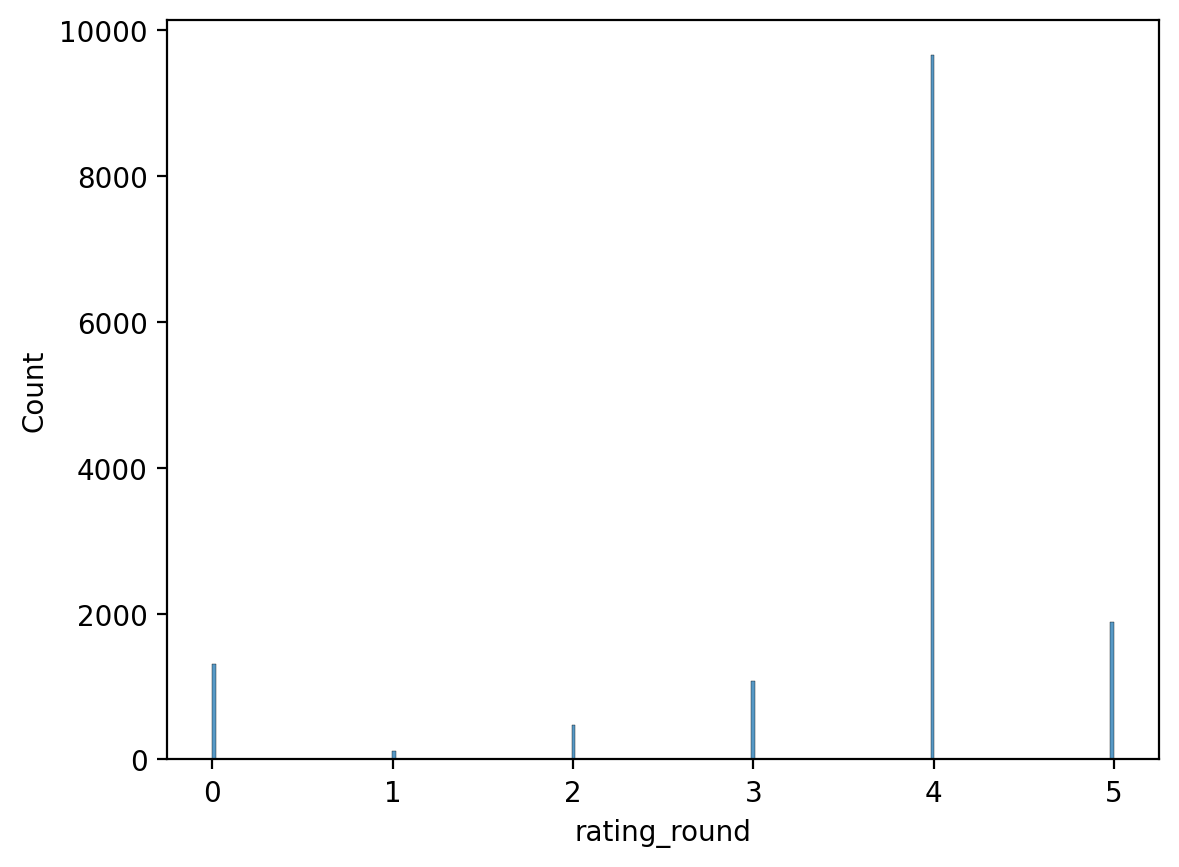

In [24]:
sns.histplot(y_train)

In [55]:
df_balance=X_train.copy()
df_balance["predict"]=y_train
df_balance=pd.concat([df_balance[df_balance["predict"]==4.0].iloc[:1900],df_balance[df_balance["predict"]!=4.0]])
df_balance

,almond,amaretto,anchovy,anise,apple,apple juice,apricot,artichoke,arugula,asian pear,...,whiskey,white wine,whole wheat,wild rice,wine,yellow squash,yogurt,yuca,zucchini,predict
17086,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
12136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
9738,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.0
12448,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.0
14191,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
8253,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8364,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
625,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


<Axes: xlabel='predict', ylabel='Count'>

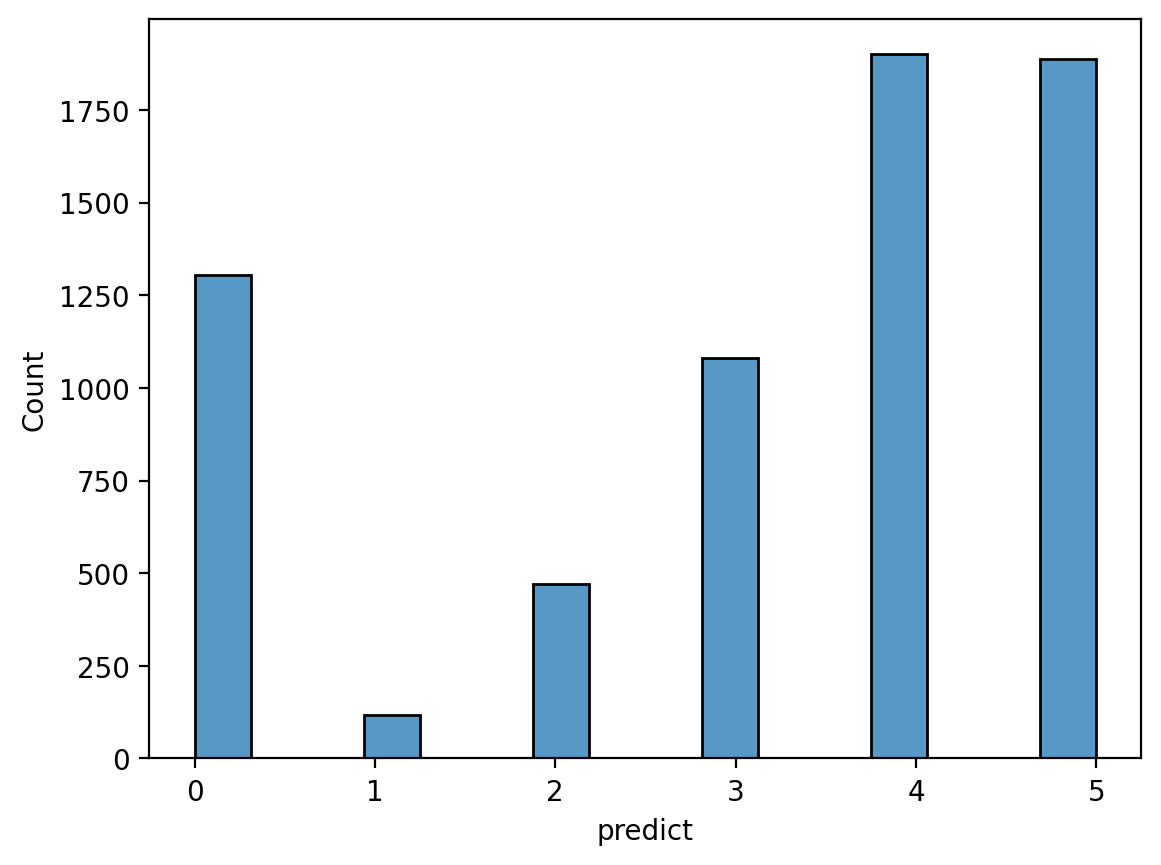

In [56]:
sns.histplot(df_balance["predict"])

In [61]:
rdf_best_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",7
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_t

In [64]:
print(classification_report(rdf_best_model.predict(X_test),y_test))

              precision    recall  f1-score   support

         0.0       0.07      0.83      0.14        29
         1.0       0.00      0.00      0.00         0
         2.0       0.00      0.00      0.00         0
         3.0       0.00      0.00      0.00         0
         4.0       1.00      0.67      0.80      3599
         5.0       0.00      0.00      0.00         0

    accuracy                           0.67      3628
   macro avg       0.18      0.25      0.16      3628
weighted avg       0.99      0.67      0.80      3628



/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true sa

In [66]:
roc_auc_score(rdf_best_model.predict(X_test),y_test)

0.8602245834570905

In [47]:
from sklearn.naive_bayes import GaussianNB
naive_G=GaussianNB()
naive_G.fit(X_train,y_train)
roc_auc_score(naive_G.predict_proba(X_test)[:,1],y_test,multi_class='ovo')

0.485128150428184

Классификация происходит чуть лучше, но из-за сильного дизбаланса классов, остальные классные предсказать практически невозможно

Перевод в качественные значения

In [48]:
qual=[]
for i in df_ingr["rating_round"]:
    if i<2:
        qual.append("Bad")
        continue
    if i<4:
        qual.append("Medium")
        continue
    else:
        qual.append("Good")
df_ingr["quality"]=qual

/tmp/ipykernel_6131/3988825653.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ingr["quality"]=qual


In [49]:
X=df_ingr.drop(columns=["rating","rating_round","quality"]+pit_vesh)
y=df_ingr["quality"]

In [50]:
X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,random_state=21,test_size=0.2,shuffle=True)

In [51]:
params_rdf={
    "n_estimators":[50],
    "max_depth":[100],
    "min_samples_split":[70]
}

In [52]:
rdf=RandomForestClassifier()
grid_s=GridSearchCV(rdf,params_rdf,n_jobs=-1,cv=3, scoring='precision')
grid_s.fit(X_train,y_train)

/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklea

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [100], 'min_samples_split': [70], 'n_estimators': [50]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also disp

In [145]:
grid_s.best_params_

{'max_depth': 100, 'min_samples_split': 70, 'n_estimators': 50}

In [146]:
print(classification_report(grid_s.predict(X_train),y_train))

              precision    recall  f1-score   support

         Bad       0.19      0.76      0.30       355
        Good       0.99      0.81      0.89     14137
      Medium       0.01      1.00      0.03        20

    accuracy                           0.81     14512
   macro avg       0.40      0.86      0.41     14512
weighted avg       0.97      0.81      0.88     14512



In [147]:
print(classification_report(grid_s.predict(X_test),y_test))

              precision    recall  f1-score   support

         Bad       0.15      0.68      0.24        76
        Good       0.99      0.81      0.89      3552
      Medium       0.00      0.00      0.00         0

    accuracy                           0.80      3628
   macro avg       0.38      0.50      0.38      3628
weighted avg       0.97      0.80      0.88      3628



/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true sa

In [92]:
joblib.dump(grid_s,"best_random_forest.joblib")

['best_random_forest.joblib']

# SVC

In [53]:
svm=SVC()
svm.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [90]:
print(classification_report(svm.predict(X_test),y_test))

              precision    recall  f1-score   support

         Bad       0.12      0.73      0.21        60
        Good       1.00      0.80      0.89      3568
      Medium       0.00      0.00      0.00         0

    accuracy                           0.80      3628
   macro avg       0.37      0.51      0.37      3628
weighted avg       0.98      0.80      0.88      3628



/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true sa

Хуже будет, если мы плохое блюда сделаем как хорошее, следовательно, лучше использовать метрику precision

# Ансамбли

In [ ]:
from sklearn.ensemble import VotingClassifier


vot_cl=VotingClassifier(estimators=[("log",log_reg),("svc",svm),("rdf",rdf)])
vot_cl.fit(X_train,y_train)

/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=0.25. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('log', ...), ('svc', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",np.float64(0....4346900318834)
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",np.float64(0.25)
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [ ]:
print(classification_report(vot_cl.predict(X_test),y_test))

              precision    recall  f1-score   support

         Bad       0.17      0.73      0.27        82
        Good       0.99      0.81      0.89      3545
      Medium       0.00      0.00      0.00         0

    accuracy                           0.81      3627
   macro avg       0.39      0.51      0.39      3627
weighted avg       0.97      0.81      0.88      3627



/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true sa

In [60]:
from sklearn.ensemble import StackingClassifier


stack_cl=StackingClassifier(estimators=[("log",log_reg),("svc",svm),("rdf",rdf)])
stack_cl.fit(X_train,y_train)

/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=0.25. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('log', ...), ('svc', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",None
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization st

In [61]:
print(classification_report(stack_cl.predict(X_test),y_test))

              precision    recall  f1-score   support

         Bad       0.18      0.72      0.28        88
        Good       0.99      0.81      0.89      3539
      Medium       0.00      0.00      0.00         0

    accuracy                           0.81      3627
   macro avg       0.39      0.51      0.39      3627
weighted avg       0.97      0.81      0.88      3627



/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sasha/Python/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/ex00/marqjodi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true sa

# Таблицы компонентов которые нужно отслеживать

In [75]:
data_nutrients = {
    'Component': [
        'Vitamin A', 'Vitamin C', 'Calcium', 'Iron', 'Vitamin D', 'Vitamin E', 'Vitamin K',
        'Thiamin', 'Riboflavin', 'Niacin', 'Vitamin B6', 'Folate', 'Vitamin B12', 'Biotin',
        'Pantothenic acid', 'Phosphorus', 'Iodine', 'Magnesium', 'Zinc', 'Selenium',
        'Copper', 'Manganese', 'Chromium', 'Molybdenum', 'Chloride', 'Potassium', 'Choline',
        'Protein'
    ],
    'ED': [
        'Micrograms RAE2 (mcg)', 'Milligrams (mg)', 'Milligrams (mg)', 'Milligrams (mg)', 
        'Micrograms (mcg)3', 'Milligrams (mg)4', 'Micrograms (mcg)', 'Milligrams (mg)',
        'Milligrams (mg)', 'Milligrams NE5 (mg)', 'Milligrams (mg)', 'Micrograms DFE7 (mcg)',
        'Micrograms (mcg)', 'Micrograms (mcg)', 'Milligrams (mg)', 'Milligrams (mg)',
        'Micrograms (mcg)', 'Milligrams (mg)', 'Milligrams (mg)', 'Micrograms (mcg)',
        'Milligrams (mg)', 'Milligrams (mg)', 'Micrograms (mcg)', 'Micrograms (mcg)',
        'Milligrams (mg)', 'Milligrams (mg)', 'Milligrams (mg)', 'Grams (g)'
    ],
    'people': [
        900, 90, 1300, 18, 20, 15, 120, 1.2, 1.3, 16, 1.7, 400, 2.4, 30, 5,
        1250, 150, 420, 11, 55, 0.9, 2.3, 35, 45, 2300, 4700, 550, 150
    ],

}

data_extra = {
    'Component': [
        'Fat', 'Saturated fat', 'Cholesterol', 'Total carbohydrates', 
        'Sodium', 'Dietary Fiber', 'Added sugars'
    ],
    'ED': [
        'Grams (g)', 'Grams (g)', 'Milligrams (mg)', 'Grams (g)',
        'Milligrams (mg)', 'Grams (g)', 'Grams (g)'
    ],
    'people': [
        78, 20, 300, 275, 2300, 28, 50]

}

df_nutrients = pd.DataFrame(data_nutrients)
df_extra = pd.DataFrame(data_extra)

df_combined = pd.concat([df_nutrients, df_extra], ignore_index=True)

In [76]:
df_combined

,Component,ED,people
0,Vitamin A,Micrograms RAE2 (mcg),900.0
1,Vitamin C,Milligrams (mg),90.0
2,Calcium,Milligrams (mg),1300.0
3,Iron,Milligrams (mg),18.0
4,Vitamin D,Micrograms (mcg)3,20.0
5,Vitamin E,Milligrams (mg)4,15.0
6,Vitamin K,Micrograms (mcg),120.0
7,Thiamin,Milligrams (mg),1.2
8,Riboflavin,Milligrams (mg),1.3
9,Niacin,Milligrams NE5 (mg),16.0


In [77]:
column=["title"]
column=column+list(df_combined["Component"])
column

['title',
 'Vitamin A',
 'Vitamin C',
 'Calcium',
 'Iron',
 'Vitamin D',
 'Vitamin E',
 'Vitamin K',
 'Thiamin',
 'Riboflavin',
 'Niacin',
 'Vitamin B6',
 'Folate',
 'Vitamin B12',
 'Biotin',
 'Pantothenic acid',
 'Phosphorus',
 'Iodine',
 'Magnesium',
 'Zinc',
 'Selenium',
 'Copper',
 'Manganese',
 'Chromium',
 'Molybdenum',
 'Chloride',
 'Potassium',
 'Choline',
 'Protein',
 'Fat',
 'Saturated fat',
 'Cholesterol',
 'Total carbohydrates',
 'Sodium',
 'Dietary Fiber',
 'Added sugars']

In [78]:
df_comp=pd.DataFrame(columns=column)

In [79]:
ingr=df_ingr.drop(columns=["rating"]+pit_vesh).columns

In [80]:
df_comp["title"]=ingr

In [81]:
df_comp

,title,Vitamin A,Vitamin C,Calcium,Iron,Vitamin D,Vitamin E,Vitamin K,Thiamin,Riboflavin,...,Potassium,Choline,Protein,Fat,Saturated fat,Cholesterol,Total carbohydrates,Sodium,Dietary Fiber,Added sugars
0,almond,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,amaretto,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,anchovy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,anise,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,apple,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,yogurt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
348,yuca,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
349,zucchini,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
350,rating_round,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Запросы к API

In [83]:
import requests

In [84]:
API_KEY = "7jnsTWmbdDqcVhkuiGJtyBBG9GVYceU83lLBYmo9"
BASE_URL = "https://api.nal.usda.gov/fdc/v1/foods/search"

In [85]:
df_ingr.columns

Index(['almond', 'amaretto', 'anchovy', 'anise', 'apple', 'apple juice',
       'apricot', 'artichoke', 'arugula', 'asian pear',
       ...
       'yogurt', 'yuca', 'zucchini', 'calories', 'protein', 'fat', 'sodium',
       'rating', 'rating_round', 'quality'],
      dtype='str', length=357)

In [86]:
r=requests.get(url=BASE_URL,params={"api_key":API_KEY,"query":["chicken"]})

In [87]:
r

<Response [200]>

In [88]:
r_js=r.json()

In [89]:
import re
def normalize_nutrient_name(name):
    return re.sub(r'[\s-]+', '', name.lower())

In [90]:
nutrients=[]
for food in r_js["foods"]:
    for nutr in food["foodNutrients"]:
        nutrients.append(str.lower(nutr["nutrientName"]))
len(nutrients)

3050

In [91]:
nutr_intr=[]
for comp in df_comp.columns:
    for nutr in nutrients:
        if normalize_nutrient_name(comp) in normalize_nutrient_name(nutr):
            nutr_intr.append(comp)
            break

In [92]:
nutr_intr=set(nutr_intr)
len(nutr_intr)

26

In [93]:
nutr_intr

{'Calcium',
 'Cholesterol',
 'Choline',
 'Copper',
 'Fat',
 'Folate',
 'Iron',
 'Magnesium',
 'Manganese',
 'Niacin',
 'Pantothenic acid',
 'Phosphorus',
 'Potassium',
 'Protein',
 'Riboflavin',
 'Selenium',
 'Sodium',
 'Thiamin',
 'Vitamin A',
 'Vitamin B12',
 'Vitamin B6',
 'Vitamin C',
 'Vitamin D',
 'Vitamin E',
 'Vitamin K',
 'Zinc'}

In [94]:
df_comp["title"].values[0]

'almond'

In [1]:
for part_eat in df_comp["title"].values:
    try:
        r=requests.get(url=BASE_URL,params={"api_key":API_KEY,"query":[part_eat]}).json()
    except:
        continue
    for food in r_js["foods"]:
        for fn in food["foodNutrients"]:
            for el in nutr_intr:
                
                if el in fn["nutrientName"]:
                    print(True)
                    df_comp.loc[df_comp["title"]==el,fn["nutrientName"]]=fn["value"]
                    continue


NameError: name 'df_comp' is not defined

In [96]:
df_comp.info()

<class 'pandas.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 67 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   title                                     352 non-null    str    
 1   Vitamin A                                 1 non-null      object 
 2   Vitamin C                                 0 non-null      object 
 3   Calcium                                   0 non-null      object 
 4   Iron                                      0 non-null      object 
 5   Vitamin D                                 0 non-null      object 
 6   Vitamin E                                 0 non-null      object 
 7   Vitamin K                                 0 non-null      object 
 8   Thiamin                                   0 non-null      object 
 9   Riboflavin                                0 non-null      object 
 10  Niacin                                    0 non-n

In [97]:
df_comp

,title,Vitamin A,Vitamin C,Calcium,Iron,Vitamin D,Vitamin E,Vitamin K,Thiamin,Riboflavin,...,"Vitamin E, added","Fatty acids, total monounsaturated","Fatty acids, total polyunsaturated","Manganese, Mn","Vitamin D (D2 + D3), International Units",Vitamin D3 (cholecalciferol),Vitamin K (Menaquinone-4),"Fatty acids, total trans-polyenoic",Vitamin K (Dihydrophylloquinone),"Fatty acids, total trans-monoenoic"
0,almond,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,amaretto,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,anchovy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,anise,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,apple,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,yogurt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
348,yuca,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
349,zucchini,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
350,rating_round,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [88]:
r_js["foods"][0]

{'fdcId': 2038064,
 'description': 'CHICKEN',
 'dataType': 'Branded',
 'gtinUpc': '796853100065',
 'publishedDate': '2021-10-28',
 'brandOwner': 'Keystone Brand Meats Inc',
 'brandName': 'KEYSTONE',
 'ingredients': 'CHICKEN, SEA SALT.',
 'marketCountry': 'United States',
 'foodCategory': 'Canned Meat',
 'modifiedDate': '2019-05-15',
 'dataSource': 'LI',
 'packageWeight': '14.5 oz/411 g',
 'servingSizeUnit': 'g',
 'servingSize': 56.0,
 'householdServingFullText': '2 ONZ',
 'tradeChannels': ['NO_TRADE_CHANNEL'],
 'allHighlightFields': '<b>Ingredients</b>: <em>CHICKEN</em>, SEA SALT.',
 'score': 959.4907,
 'microbes': [],
 'foodNutrients': [{'nutrientId': 1003,
   'nutrientName': 'Protein',
   'nutrientNumber': '203',
   'unitName': 'G',
   'derivationCode': 'LCCS',
   'derivationDescription': 'Calculated from value per serving size measure',
   'derivationId': 70,
   'value': 21.4,
   'foodNutrientSourceId': 9,
   'foodNutrientSourceCode': '12',
   'foodNutrientSourceDescription': "Manuf

In [90]:
for i in r_js["foods"][0]["foodNutrients"]:
    print(i["nutrientName"])

Protein
Total lipid (fat)
Carbohydrate, by difference
Energy
Total Sugars
Fiber, total dietary
Calcium, Ca
Iron, Fe
Sodium, Na
Vitamin A, IU
Vitamin C, total ascorbic acid
Cholesterol
Fatty acids, total trans
Fatty acids, total saturated


In [94]:
r_js["foods"][0]["foodNutrients"][7]

{'nutrientId': 1089,
 'nutrientName': 'Iron, Fe',
 'nutrientNumber': '303',
 'unitName': 'MG',
 'derivationCode': 'LCCD',
 'derivationDescription': 'Calculated from a daily value percentage per serving size measure',
 'derivationId': 75,
 'value': 0.0,
 'foodNutrientSourceId': 9,
 'foodNutrientSourceCode': '12',
 'foodNutrientSourceDescription': "Manufacturer's analytical; partial documentation",
 'rank': 5400,
 'indentLevel': 1,
 'foodNutrientId': 25017831,
 'percentDailyValue': 0}